In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns
import ast

import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import matplotlib.dates as mdates
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec


In [23]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')

pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. CONSTRUCCIÓN DE TRASLADOS (El core del modelo)
# ==========================================

# Asocia los traslados con la fila de abajo
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)

# --- ACÁ ESTÁ EL ARREGLO 1: GUARDAMOS EL ESTADO Y EL TIPO DE DESTINO ---
pacientes['estado_destino'] = pacientes.groupby('paciente_id')['estado_ingreso'].shift(-1)
pacientes['tipo_destino'] = pacientes.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos' 
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0

motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']

mask_traslados = (
    pacientes['hospital_destino'].notna() & 
    pacientes['motivo_egreso'].isin(motivos_validos) & 
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) 
)
df_potenciales = pacientes[mask_traslados].copy() 

# DF Auxiliar: Traslados que tardaron MÁS de 30 días
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()

# DF Principal de Traslados (<= 100 días)
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# ==========================================
# 3. DF DE TRAYECTORIAS (Reconstrucción completa ampliada)
# ==========================================

dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))

mapa_estados = {
    'criticas': 3,
    'intermedias': 2,
    'generales': 1
}

# --- ACÁ ESTÁ EL ARREGLO 2: LA FUNCIÓN AHORA PERSIGUE EL TIPO DE INGRESO ---
def armar_trayectoria(group):
    ruta_hosp = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    ruta_tipo = group['tipo_ingreso'].tolist() + [group['tipo_destino'].iloc[-1]]
    
    ruta_comp_num = [dict_complejidad.get(h, 0) for h in ruta_hosp] 
    ruta_tipo_num = [mapa_estados.get(str(e).lower().strip(), 0) for e in ruta_tipo]

    str_hosp = " -> ".join(ruta_hosp)
    str_tipo = " -> ".join([str(e) for e in ruta_tipo])
    str_comp = " -> ".join([str(c) for c in ruta_comp_num])
    str_tipo_num = " -> ".join([str(e) for e in ruta_tipo_num])

    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales_str': str_hosp,
        'ruta_tipos_str': str_tipo,
        'ruta_tipos_num_str': str_tipo_num,
        'ruta_complejidad_str': str_comp,
        
        'ruta_hospitales_array': ruta_hosp,
        'ruta_tipos_array': ruta_tipo,
        'ruta_tipos_num_array': ruta_tipo_num,
        'ruta_complejidad_array': ruta_comp_num,
        
        'hospital_final': ruta_hosp[-1],
        'tipo_final_txt': ruta_tipo[-1],
        'tipo_final_num': ruta_tipo_num[-1],
        'complejidad_final': ruta_comp_num[-1],
        
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()


In [24]:
# paciente_testigo = 'WN04'
# display(pacientes[pacientes['paciente_id'] == paciente_testigo][['fecha_ingreso', 'hospital_origen', 'motivo_egreso', 'fecha_egreso', 'hospital_destino', 'dias_traslado', 'riesgo_clinico']])

# # Ver las 5 trayectorias con más traslados
# display(df_trayectoria.sort_values('cantidad_traslados', ascending=False).head(5))

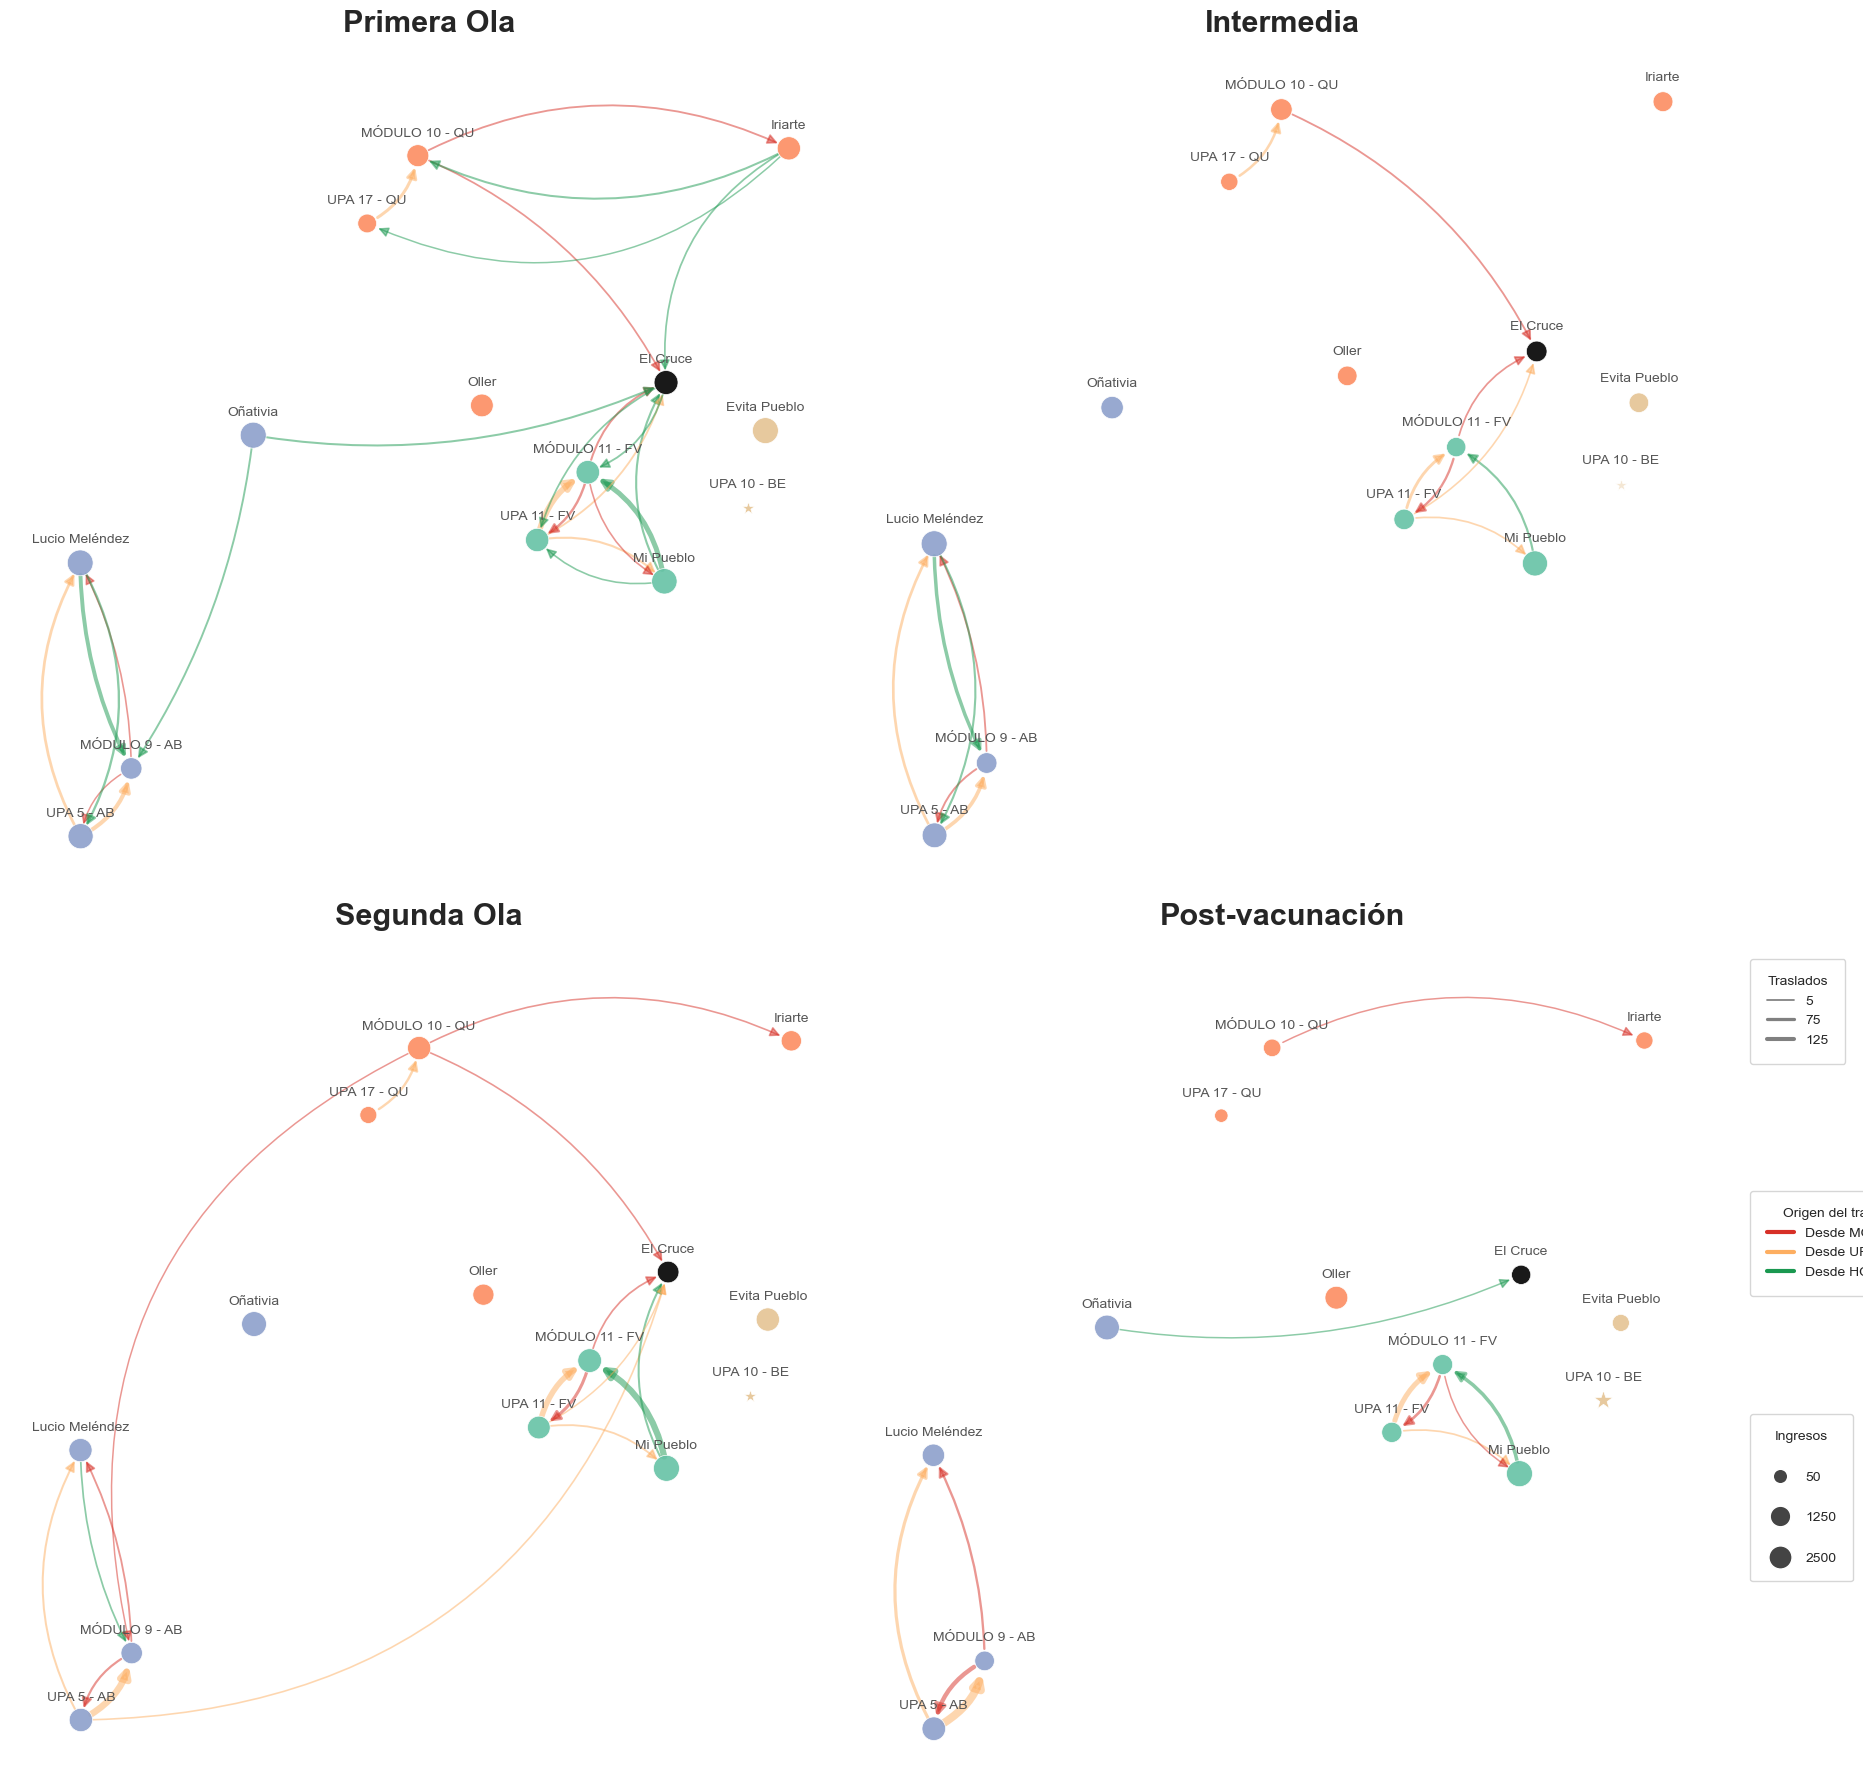

In [25]:
# ==========================================
# 3. PREPARACIÓN DE COORDENADAS
# ==========================================
df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
    # No renombramos 'color' y 'shape' porque ya tienen buenos nombres
})

# Separación de hospitales con mismas coordenadas
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []

for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        primeras = True
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if primeras:
                primeras = False
            else:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
# --- AJUSTE MANUAL DE POSICIONES PARA VISIBILIDAD ---
# Módulo 8 - LZ: Lo movemos a la derecha (sumamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.07
# UPA 10 - BE: Lo movemos a la izquierda (restamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.08
# EVITA PUEBLO: Lo movemos a la izquierda (restamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.04

# Traductor de formas para NetworkX
mapa_formas = {
    'dot': 'o',   # Círculo
    'star': '*'   # Estrella
}

# ==========================================
# 4. CONFIGURACIÓN VISUAL
# ==========================================
periodos = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]



# ==========================================
# 5. CÁLCULOS GLOBALES Y ESCALAS (PREVIO AL DIBUJO)
# ==========================================
# Constantes de diseño ajustadas para Raíz Cuadrada
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 8.0
MIN_TAMANO_NODO = 80     
MAX_TAMANO_NODO = 350   

hospitales_conocidos = set(df_coordenadas['hospital'])

# Cálculos globales para referencias y leyendas
agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1
pesos_filtrados = agrupado_global[agrupado_global > 2]

if not pesos_filtrados.empty:
    min_t = int(pesos_filtrados.min())
    med_t = int(np.median(pesos_filtrados))
    max_t = int(pesos_filtrados.max())
else:
    min_t, med_t, max_t = 3, 5, 10

ingresos_globales = pacientes['hospital_origen'].value_counts()
MAX_INGRESOS_GLOBAL = ingresos_globales.max() if not ingresos_globales.empty else 1
ingresos_filtrados = ingresos_globales[ingresos_globales > 0]

if not ingresos_filtrados.empty:
    min_i = int(ingresos_filtrados.min())
    med_i = int(np.median(ingresos_filtrados))
    max_i = int(ingresos_filtrados.max())
else:
    min_i, med_i, max_i = 10, 50, 100

def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def calc_markersize(ingreso):
    escala = np.sqrt(ingreso) / np.sqrt(MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
    area = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return np.sqrt(area)

# ==========================================
# 6. DIBUJO DEL GRÁFICO (GRILLA 2x2 - ESTILO ACTUALIZADO)
# ==========================================

def asignar_color_tipo(nombre_hospital):
    nombre_norm = nombre_hospital.upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm:
        return '#d73027'  # Rojo
    elif 'UPA' in nombre_norm:
        return '#fdae61'  # Naranja
    else:
        return '#1a9850'  # Verde

fig, axes = plt.subplots(2, 2, figsize=(22, 18))
fig.patch.set_facecolor('white')
axes_flat = axes.flatten()

# Para las leyendas finales, guardaremos los valores máximos encontrados en todos los periodos
v_max_encontrado = 0
i_max_encontrado = 0

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes_flat[idx]
    ax.set_title(titulo, fontsize=22, fontweight='bold', pad=20)
    
    # 1. FILTRADO
    mask_ingresos = (pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)
    ingresos_periodo_ser = pacientes[mask_ingresos]['hospital_origen'].value_counts()
    ingresos_por_hospital = ingresos_periodo_ser.to_dict()
    
    mask_tras = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_periodo_traslados = df_traslados[mask_tras].copy()
    traslados_agrupados = df_periodo_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    
    # Traslados visibles (> 4)
    traslados_dibujables = traslados_agrupados[traslados_agrupados['peso'] > 2]
    
    # Actualizar máximos para la leyenda global
    if not traslados_dibujables.empty:
        v_max_encontrado = max(v_max_encontrado, traslados_dibujables['peso'].max())
    if not ingresos_periodo_ser.empty:
        i_max_encontrado = max(i_max_encontrado, ingresos_periodo_ser.max())

    G = nx.DiGraph()

# 2. AÑADIR NODOS
    for _, row in df_coordenadas.iterrows():
        h = row['hospital']
        n_ing = ingresos_por_hospital.get(h, 0)
        
        # Escala basada en el máximo del periodo actual
        escala_n = np.sqrt(n_ing) / np.sqrt(ingresos_periodo_ser.max()) if not ingresos_periodo_ser.empty and n_ing > 0 else 0
        tamano_nodo = MIN_TAMANO_NODO + (escala_n * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
        
        try: color_rgb = ast.literal_eval(str(row['color']))
        except: color_rgb = 'grey'
            
        forma_nodo = mapa_formas.get(row['shape'], 'o')
        
        # --- CAMBIO 1: Subimos el alpha de 0.05 a 0.4 para que los nodos inactivos se vean ---
        alpha_val = 0.9 if n_ing > 0 else 0.4
        
        G.add_node(h, pos=(row['lon'], row['lat']), color=color_rgb, size=tamano_nodo, shape=forma_nodo, alpha=alpha_val)

    # 3. AÑADIR ARISTAS
    for _, row_t in traslados_dibujables.iterrows():
        u, v = row_t['hospital_ingreso'], row_t['hospital_destino']
        if u in hospitales_conocidos and v in hospitales_conocidos:
            G.add_edge(u, v, weight=row_t['peso'])

    posiciones = nx.get_node_attributes(G, 'pos')
    
    # 4. DIBUJAR
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    for forma in formas_presentes:
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nx.draw_networkx_nodes(G, posiciones, nodelist=nodelist, ax=ax, 
                               node_shape=forma, 
                               node_color=[G.nodes[n]['color'] for n in nodelist], 
                               node_size=[G.nodes[n]['size'] for n in nodelist], 
                               alpha=[G.nodes[n]['alpha'] for n in nodelist],
                               edgecolors='white', linewidths=0.5)

    for u, v, data in G.edges(data=True):
        peso = data['weight']
        escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

        color_flecha = asignar_color_tipo(u)
    
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 85 - 35) / 100.0
        if abs(rad_dinamico) < 0.12: rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                                width=grosor, edge_color=color_flecha, alpha=0.5,
                                arrowstyle='-|>', arrowsize=15, 
                                connectionstyle=f"arc3,rad={rad_dinamico}")

    # --- CAMBIO 2: Quitamos el "if" para que TODOS los nodos del mapa tengan su etiqueta ---
    labels = {n: n.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO') 
              for n in G.nodes()}
    pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}
    
    # Le bajamos un poquito el color a las letras (#555555) para que no sature el mapa con tanto texto
    nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=10, font_color='#555555')

    ax.axis('off')
    
# ==========================================
# 7. LEYENDAS MANUALES (PONER AQUÍ)
# ==========================================

# 1. Definimos el eje de referencia (el último de la grilla)
ax_ref = axes_flat[-1] 

# 2. Creamos los objetos "Proxy" (No dibujan nada en el mapa, solo existen para la leyenda)
# Usamos los máximos reales que calculamos durante el bucle


# v_min_leg = 5
# v_max_leg = int(v_max_encontrado)
# v_med_leg = int(((np.sqrt(v_min_leg) + np.sqrt(v_max_leg)) / 2) ** 2)

# Función para redondear a números "humanos" (10, 50, 100...)
def redondear_estetico(valor):
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    return int(np.ceil(valor / 50) * 50)

# --- Para los Traslados (Grosor) ---
v_max_leg = redondear_estetico(v_max_encontrado)
v_min_leg = 5  # Mantenemos el umbral mínimo que definiste
v_med_leg = redondear_estetico((v_min_leg + v_max_leg) / 2)

# --- Para los Ingresos (Tamaño Nodo) ---
i_max_leg = redondear_estetico(i_max_encontrado)
i_min_leg = 50 
i_med_leg = redondear_estetico(i_max_leg / 2)



# --- Referencias de Volumen (Grosor) ---
lineas_volumen = [
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_min_leg), label=f'{int(v_min_leg)}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_med_leg)/2, label=f'{int(v_med_leg/2)}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_max_leg)/2, label=f'{int(v_max_leg/2)}')
]

# --- Referencias de Origen (Color) ---
lineas_colores = [
    mlines.Line2D([], [], color='#d73027', lw=3, label='Desde MÓDULO'),
    mlines.Line2D([], [], color='#fdae61', lw=3, label='Desde UPA'),
    mlines.Line2D([], [], color='#1a9850', lw=3, label='Desde HOSPITAL')
]

# # --- Referencias de Ingresos (Tamaño de Nodo) ---
# i_min_leg = 10
# i_max_leg = int(i_max_encontrado)
# i_med_leg = int(((np.sqrt(i_min_leg) + np.sqrt(i_max_leg)) / 2) ** 2)

nodos_ingresos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_min_leg), label=f'{i_min_leg}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_med_leg), label=f'{i_med_leg}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_max_leg), label=f'{i_max_leg}')
]

# 3. Agregamos las leyendas al eje usando bbox_to_anchor para que floten a la derecha
leg1 = ax_ref.legend(handles=lineas_volumen, title="Traslados", 
                     loc='upper left', bbox_to_anchor=(1.05, 1), frameon=True, borderpad=1.2)
ax_ref.add_artist(leg1)

leg2 = ax_ref.legend(handles=lineas_colores, title="Origen del traslado", 
                     loc='upper left', bbox_to_anchor=(1.05, 0.72), frameon=True, borderpad=1.2)
ax_ref.add_artist(leg2)

leg3 = ax_ref.legend(handles=nodos_ingresos, title="Ingresos", 
                     loc='upper left', bbox_to_anchor=(1.05, 0.45), frameon=True, borderpad=1.2, labelspacing=2)

# 4. AJUSTE FINAL DE LA FIGURA
plt.tight_layout(rect=[0, 0, 0.85, 1]) # El 0.85 deja el 15% derecho libre para las leyendas
plt.show()

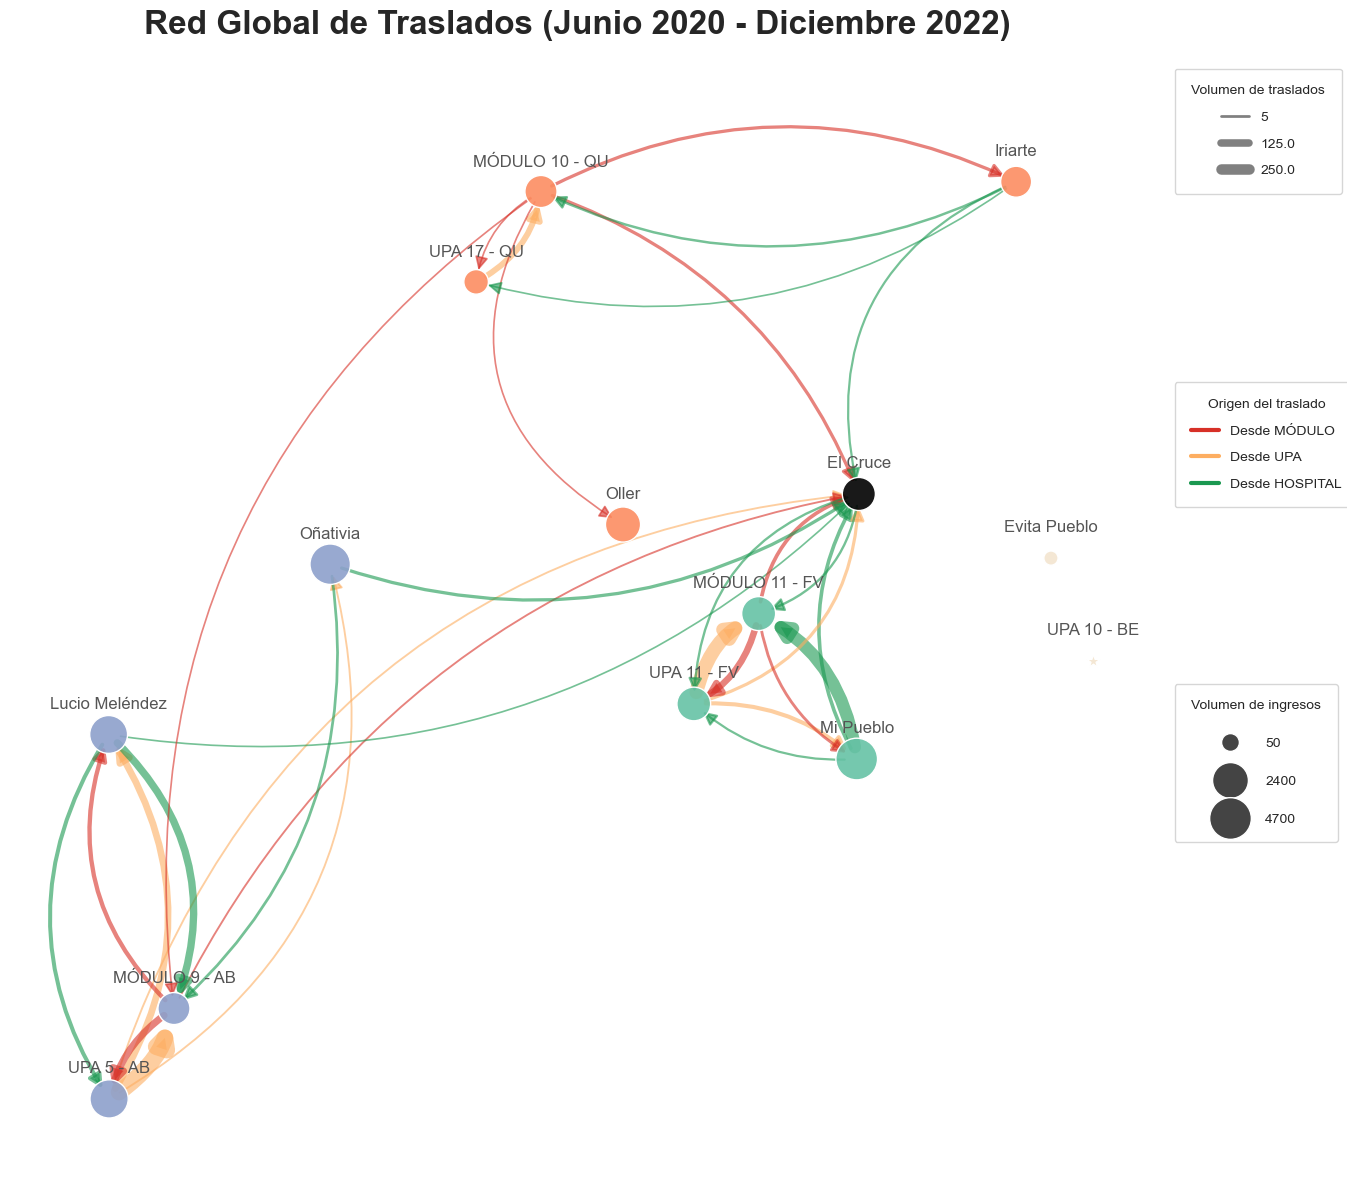

In [26]:
# ==========================================
# 1. CARGA DE DATOS Y LIMPIEZA. NOMENCLATURAS Y FECHAS
# ==========================================

pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',

    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',

    'Sexo': 'sexo',
    'Edad': 'edad',

    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',

    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',

    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',

    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',

    'Asistencia Respiratoria Mecánica': 'requiere_arm',

    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',

    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',

    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')

pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================
# 2. CONSTRUCCIÓN DE TRASLADOS (El core del modelo)
# ==========================================

# Asocia los traslados con la fila de abajo
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)

# --- ACÁ ESTÁ EL ARREGLO 1: GUARDAMOS EL ESTADO Y EL TIPO DE DESTINO ---
pacientes['estado_destino'] = pacientes.groupby('paciente_id')['estado_ingreso'].shift(-1)
pacientes['tipo_destino'] = pacientes.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos' 
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0

motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']

mask_traslados = (
    pacientes['hospital_destino'].notna() & 
    pacientes['motivo_egreso'].isin(motivos_validos) & 
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) 
)
df_potenciales = pacientes[mask_traslados].copy() 

# DF Auxiliar: Traslados que tardaron MÁS de 30 días
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()

# DF Principal de Traslados (<= 100 días)
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# ==========================================
# 3. DF DE TRAYECTORIAS (Reconstrucción completa ampliada)
# ==========================================

dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))

mapa_estados = {
    'criticas': 3,
    'intermedias': 2,
    'generales': 1
}

# --- ACÁ ESTÁ EL ARREGLO 2: LA FUNCIÓN AHORA PERSIGUE EL TIPO DE INGRESO ---
def armar_trayectoria(group):
    ruta_hosp = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    ruta_tipo = group['tipo_ingreso'].tolist() + [group['tipo_destino'].iloc[-1]]
    
    ruta_comp_num = [dict_complejidad.get(h, 0) for h in ruta_hosp] 
    ruta_tipo_num = [mapa_estados.get(str(e).lower().strip(), 0) for e in ruta_tipo]

    str_hosp = " -> ".join(ruta_hosp)
    str_tipo = " -> ".join([str(e) for e in ruta_tipo])
    str_comp = " -> ".join([str(c) for c in ruta_comp_num])
    str_tipo_num = " -> ".join([str(e) for e in ruta_tipo_num])

    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales_str': str_hosp,
        'ruta_tipos_str': str_tipo,
        'ruta_tipos_num_str': str_tipo_num,
        'ruta_complejidad_str': str_comp,
        
        'ruta_hospitales_array': ruta_hosp,
        'ruta_tipos_array': ruta_tipo,
        'ruta_tipos_num_array': ruta_tipo_num,
        'ruta_complejidad_array': ruta_comp_num,
        
        'hospital_final': ruta_hosp[-1],
        'tipo_final_txt': ruta_tipo[-1],
        'tipo_final_num': ruta_tipo_num[-1],
        'complejidad_final': ruta_comp_num[-1],
        
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()


# Podés probar ver un caso particular para confirmar que todo ande bien:
# display(df_trayectoria.head())

# Mostramos cómo quedaron (opcional)
# print("Traslados listos para el grafo:", len(df_traslados))
# print("Traslados anómalos (>30 días):", len(df_mas_30_dias))
#display(df_trayectoria.head())
# ==========================================
# 3. PREPARACIÓN DE COORDENADAS (CON AJUSTES MANUALES)
# ==========================================
df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
})

# --- MOVIMIENTOS MANUALES PARA EVITAR CORTES EN MÁRGENES ---
# Módulo 8 - LZ: Lo movemos a la derecha (sumamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06

# UPA 10 - BE: Lo movemos a la izquierda (restamos a lon)
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06

# Evita Pueblo: Lo alejamos un poco del borde derecho
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Procesamiento de duplicados (se mantiene igual)
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []
for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if i > 0:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)

# ==========================================
# 4. CONFIGURACIÓN VISUAL
# ==========================================
periodos = [
    ('Primera Ola', '2020-06-01', '2020-10-31'),
    ('Intermedia', '2020-11-01', '2021-02-28'),
    ('Segunda Ola', '2021-03-01', '2021-07-31'),
    ('Post-vacunación', '2021-08-01', '2022-12-31')
]

# ==========================================
# 5. CÁLCULOS GLOBALES Y ESCALAS (PREVIO AL DIBUJO)
# ==========================================
# Constantes de diseño ajustadas para Raíz Cuadrada
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 15.0
MIN_TAMANO_NODO = 80     
MAX_TAMANO_NODO = 900   

hospitales_conocidos = set(df_coordenadas['hospital'])

# Cálculos globales para referencias y leyendas
agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size()
MAX_TRASLADOS_GLOBAL = agrupado_global.max() if not agrupado_global.empty else 1
pesos_filtrados = agrupado_global[agrupado_global > 2]

if not pesos_filtrados.empty:
    min_t = int(pesos_filtrados.min())
    med_t = int(np.median(pesos_filtrados))
    max_t = int(pesos_filtrados.max())
else:
    min_t, med_t, max_t = 3, 5, 10

ingresos_globales = pacientes['hospital_origen'].value_counts()
MAX_INGRESOS_GLOBAL = ingresos_globales.max() if not ingresos_globales.empty else 1
ingresos_filtrados = ingresos_globales[ingresos_globales > 0]

if not ingresos_filtrados.empty:
    min_i = int(ingresos_filtrados.min())
    med_i = int(np.median(ingresos_filtrados))
    max_i = int(ingresos_filtrados.max())
else:
    min_i, med_i, max_i = 10, 50, 100

def calc_grosor(peso):
    escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def calc_markersize(ingreso):
    escala = np.sqrt(ingreso) / np.sqrt(MAX_INGRESOS_GLOBAL) if MAX_INGRESOS_GLOBAL > 0 else 0
    area = MIN_TAMANO_NODO + (escala * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return np.sqrt(area)

# ==========================================
# 6. DIBUJO DEL GRÁFICO GLOBAL (DEFINITIVO)
# ==========================================
MIN_TAMANO_NODO_GLOBAL = 150
MAX_TAMANO_NODO_GLOBAL = 900  

MIN_GROSOR_ARISTA_GLOBAL = 0.3
MAX_GROSOR_ARISTA_GLOBAL = 12.0 

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')

ax.set_title('Red Global de Traslados (Junio 2020 - Diciembre 2022)', fontsize=24, fontweight='bold', pad=20)

# ---------------------------------------------------------
# 1. FILTRAMOS ESTRICTAMENTE LO QUE SE VA A DIBUJAR
# ---------------------------------------------------------
# Filtramos traslados válidos entre hospitales que tenemos en coordenadas
# Y EXCLUIMOS LOS TRASLADOS A SÍ MISMOS (self-loops)
mask_validos = (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & \
               (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & \
               (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])

df_traslados_validos = df_traslados[mask_validos]
traslados_agrupados_global = df_traslados_validos.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')

# ¡CLAVE! Nos quedamos únicamente con los traslados que superan el umbral visual (> 4)
traslados_dibujables = traslados_agrupados_global[traslados_agrupados_global['peso'] > 2]

# Calculamos el MÁXIMO REAL de las aristas visibles
MAX_TRASLADOS_REAL = traslados_dibujables['peso'].max() if not traslados_dibujables.empty else 1

if not traslados_dibujables.empty:
    min_t_real = int(traslados_dibujables['peso'].min())
    max_t_real = int(traslados_dibujables['peso'].max())
    # Calculamos el valor que da exactamente el grosor intermedio visual
    med_t_real = int(((np.sqrt(min_t_real) + np.sqrt(max_t_real)) / 2) ** 2)
else:
    min_t_real, med_t_real, max_t_real = 3, 5, 10

# Identificamos qué hospitales participan de estas conexiones visibles
hospitales_conectados = set(traslados_dibujables['hospital_ingreso']).union(set(traslados_dibujables['hospital_destino']))

# Filtramos los ingresos SOLO para los hospitales que están conectados en el dibujo
ingresos_globales_ser = pacientes[pacientes['hospital_origen'].isin(hospitales_conectados)]['hospital_origen'].value_counts()
ingresos_por_hospital_global = ingresos_globales_ser.to_dict()

# Calculamos el MÁXIMO REAL de nodos visibles
MAX_INGRESOS_REAL = ingresos_globales_ser.max() if not ingresos_globales_ser.empty else 1

ingresos_reales = ingresos_globales_ser[ingresos_globales_ser > 0]
if not ingresos_reales.empty:
    min_i_real = int(ingresos_reales.min())
    max_i_real = int(ingresos_reales.max())
    # Calculamos el valor que da exactamente el tamaño de círculo intermedio visual
    med_i_real = int(((np.sqrt(min_i_real) + np.sqrt(max_i_real)) / 2) ** 2)
else:
    min_i_real, med_i_real, max_i_real = 10, 50, 100

G = nx.DiGraph()

# ---------------------------------------------------------
# 2. DIBUJAR NODOS
# ---------------------------------------------------------
for _, row in df_coordenadas.iterrows():
    h = row['hospital']
    n_ing = ingresos_por_hospital_global.get(h, 0)
    
    # Si tiene ingresos, escalamos el tamaño. Si no, tamaño mínimo.
    if n_ing > 0:
        escala_n = np.sqrt(n_ing) / np.sqrt(MAX_INGRESOS_REAL)
        tamano_nodo = MIN_TAMANO_NODO_GLOBAL + (escala_n * (MAX_TAMANO_NODO_GLOBAL - MIN_TAMANO_NODO_GLOBAL))
        alpha_val = 0.9  # Nodos activos: bien sólidos
    else:
        tamano_nodo = MIN_TAMANO_NODO_GLOBAL * 0.7 # Un poco más chicos que el mínimo activo
        alpha_val = 0.4  # <-- AJUSTADO: 0.4 para que sean visibles aunque no tengan actividad

    try:
        color_rgb = ast.literal_eval(str(row['color']))
    except:
        color_rgb = 'grey'
        
    forma_nodo = mapa_formas.get(row['shape'], 'o')
    
    G.add_node(h, pos=(row['lon'], row['lat']), color=color_rgb, 
               size=tamano_nodo, shape=forma_nodo, alpha=alpha_val)

# ---------------------------------------------------------
# 3. DIBUJAR ARISTAS (Colores originales según tipo de ORIGEN)
# ---------------------------------------------------------

def asignar_color_original(nombre_hospital):
    nombre_norm = nombre_hospital.upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm:
        return '#d73027'  # Rojo original
    elif 'UPA' in nombre_norm:
        return '#fdae61'  # Naranja original
    else:
        return '#1a9850'  # Verde original

# Agregamos las aristas al grafo
for _, row_t in traslados_dibujables.iterrows():
    G.add_edge(row_t['hospital_ingreso'], row_t['hospital_destino'], weight=row_t['peso'])

posiciones = nx.get_node_attributes(G, 'pos')

# --- Renderizar Nodos ---
formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
for forma in formas_presentes:
    nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
    nx.draw_networkx_nodes(G, posiciones, nodelist=nodelist, ax=ax, 
                           node_shape=forma, 
                           node_color=[G.nodes[n]['color'] for n in nodelist], 
                           node_size=[G.nodes[n]['size'] for n in nodelist], 
                           alpha=[G.nodes[n]['alpha'] for n in nodelist],
                           edgecolors='white', linewidths=1.0)

# --- Renderizar Aristas con Colores por Origen ---
for u, v, data in G.edges(data=True):
    peso = data['weight']
    
    # Grosor sigue dependiendo del volumen de traslados
    escala_peso = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_REAL)
    grosor = MIN_GROSOR_ARISTA_GLOBAL + (escala_peso * (MAX_GROSOR_ARISTA_GLOBAL - MIN_GROSOR_ARISTA_GLOBAL))

    # El COLOR ahora depende de QUIÉN ENVÍA (u)
    color_flecha = asignar_color_original(u)

    # Curvatura para evitar que las flechas ida/vuelta se tapen
    suma_caracteres = sum(ord(c) for c in u + v)
    rad_dinamico = (suma_caracteres % 90 - 35) / 100.0
    if abs(rad_dinamico) < 0.12:
        rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

    nx.draw_networkx_edges(G, posiciones, edgelist=[(u, v)], ax=ax,
                            width=grosor, edge_color=color_flecha, alpha=0.6,
                            arrowstyle='-|>', arrowsize=20, 
                            connectionstyle=f"arc3,rad={rad_dinamico}")

# ---------------------------------------------------------
# 4. ETIQUETAS
# ---------------------------------------------------------
labels = {}
for k in G.nodes():
    # <-- ELIMINADO EL IF: Ahora todos los hospitales reciben su nombre
    nombre_corto = k.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO')
    labels[k] = nombre_corto

pos_labels = {k: (v[0], v[1] + 0.005) for k, v in posiciones.items() if k in labels}

nx.draw_networkx_labels(G, pos_labels, labels=labels, ax=ax, font_size=12,
                    font_weight='medium', font_color='#555555', font_family='sans-serif')

ax.axis('off')

# ==========================================
# 7. LEYENDAS (Sincronizadas y Limpias - GLOBAL)
# ==========================================

# --- Función de Redondeo Estético (Asegura múltiplos de 10, 50 o 100) ---
def redondear_estetico(valor):
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    if valor <= 500: return int(np.ceil(valor / 50) * 50)
    return int(np.ceil(valor / 100) * 100)

# 1. Cálculo de valores REDONDEADOS para Traslados (Grosor)
if not traslados_dibujables.empty:
    v_max_g = redondear_estetico(traslados_dibujables['peso'].max())
    v_min_g = 5  
    v_med_g = redondear_estetico(v_max_g / 2)
else:
    v_min_g, v_med_g, v_max_g = 5, 10, 20

# 2. Cálculo de valores REDONDEADOS para Ingresos (Tamaño Nodo)
if not ingresos_reales.empty:
    i_max_g = redondear_estetico(ingresos_reales.max())
    i_min_g = 50 # Mantenemos un mínimo visual estándar
    # Calculamos el medio y lo redondeamos para que la leyenda sea estética
    i_med_g = redondear_estetico(i_max_g / 2)
else:
    i_min_g, i_med_g, i_max_g = 10, 50, 100

# 3. Creación de Objetos Proxy con los nuevos valores redondeados
# --- Traslados (Grosor) ---
proxies_volumen = [
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_min_g), label=f'{v_min_g}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_med_g)/2, label=f'{v_med_g/2}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_max_g)/2, label=f'{v_max_g/2}')
]

# --- Origen (Color) ---
proxies_colores = [
    mlines.Line2D([], [], color='#d73027', lw=3, label='Desde MÓDULO'),
    mlines.Line2D([], [], color='#fdae61', lw=3, label='Desde UPA'),
    mlines.Line2D([], [], color='#1a9850', lw=3, label='Desde HOSPITAL')
]

# --- Ingresos (Tamaño Nodo) - AHORA REDONDEADOS ---
proxies_nodos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_min_g), label=f'{i_min_g}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_med_g), label=f'{i_med_g}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=calc_markersize(i_max_g), label=f'{i_max_g}')
]

# (El resto del código de renderizado de leyendas y plt.show() se mantiene igual)

# 3. Renderizado de Leyendas al costado del eje 'ax'
# Leyenda de Volumen
leg1 = ax.legend(handles=proxies_volumen, title="Volumen de traslados", 
                 loc='upper left', bbox_to_anchor=(1.02, 1), 
                 frameon=True, borderpad=1.2, labelspacing=1)
ax.add_artist(leg1)

# Leyenda de Origen
leg2 = ax.legend(handles=proxies_colores, title="Origen del traslado", 
                 loc='upper left', bbox_to_anchor=(1.02, 0.72), 
                 frameon=True, borderpad=1.2, labelspacing=1)
ax.add_artist(leg2)

# Leyenda de Actividad
leg3 = ax.legend(handles=proxies_nodos, title="Volumen de ingresos", 
                 loc='upper left', bbox_to_anchor=(1.02, 0.45), 
                 frameon=True, borderpad=1.2, labelspacing=1.8, handletextpad=1.5)

# 4. Ajuste de márgenes para que entren las leyendas
plt.tight_layout(rect=[0, 0, 0.85, 1]) 
plt.show()

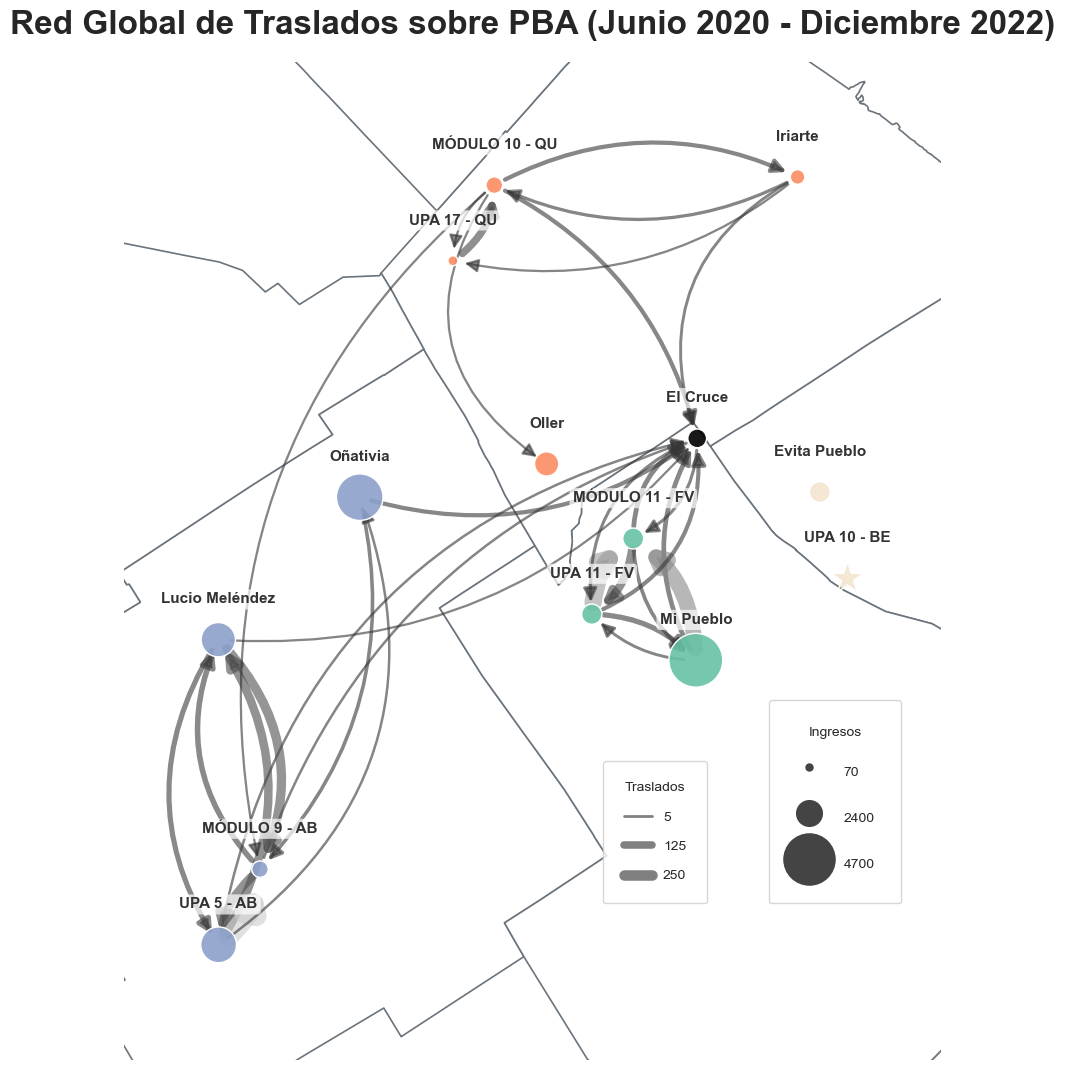

In [28]:
############################################################
# RED DE TRASLADOS HOSPITALARIOS - MAPA PBA
############################################################

import ast
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.lines as mlines


import os # Por las dudas, lo agregamos acá si no lo importaste arriba

# ... [todo tu código anterior hasta leg3 = ax.legend(...)] ...


# ==========================================================
# 1. CARGA DE DATOS Y LIMPIEZA INICIAL
# ==========================================================

pacientes = pd.read_excel("C:/Users/micag/Documents/RedesHospitales/data/pacientes.xlsx")
hospitales = pd.read_csv("C:/Users/micag/Documents/RedesHospitales/data/hospitales_coordenadas.csv")

# Parseo de colores y formas para el mapa
hospitales['color_rgb'] = hospitales['color'].apply(ast.literal_eval)
hospitales['forma_nodo'] = hospitales['shape'].map({'dot': 'o', 'star': '*'})

# Renombramiento de columnas para estandarizar
pacientes = pacientes.rename(columns={
    'Id Hospital': 'hospital_id',
    'Nombre Hospital': 'hospital_origen',
    'Id': 'paciente_id',
    'Fecha inicio': 'fecha_ingreso',
    'Estado al ingreso': 'estado_ingreso',
    'Tipo al ingreso': 'tipo_ingreso',
    'Último estado': 'estado_ultimo',
    'Último tipo': 'tipo_ultimo',
    'Sexo': 'sexo',
    'Edad': 'edad',
    'Nivel riesgo clínico': 'riesgo_clinico',
    'Nivel riesgo social': 'riesgo_social',
    'Enfermedades preexistentes Covid-19': 'comorbilidades_covid',
    'Enfermedades preexistentes pediatría': 'comorbilidades_pediatria',
    'Vacuna': 'vacuna',
    'Cant. dosis': 'cantidad_dosis',
    '1º dosis': 'fecha_dosis_1',
    '2º dosis': 'fecha_dosis_2',
    'Buscado en el ministerio': 'validado_ministerio',
    'Obra social': 'obra_social',
    'Asistencia Respiratoria Mecánica': 'requiere_arm',
    'Motivo': 'motivo_egreso',
    'Operación': 'operacion',
    'Fecha egreso': 'fecha_egreso',
    'Última actualización': 'fecha_ultima_actualizacion',
    'Pasó por Críticas': 'paso_criticas',
    'Pasó por Intermedias': 'paso_intermedias',
    'Pasó por Generales': 'paso_generales'
}).copy()

# Corrección de nomenclaturas
pacientes['hospital_origen'] = pacientes['hospital_origen'].replace({
    'Módulo Hospitalario 11- FV': 'Módulo Hospitalario 11 - FV',
    'Módulo Hospitalario  9 - AB': 'Módulo Hospitalario 9 - AB'
})

# Estandarización de fechas y ordenamiento
pacientes['fecha_ingreso'] = pd.to_datetime(pacientes['fecha_ingreso'], errors='coerce')
pacientes['fecha_egreso'] = pd.to_datetime(pacientes['fecha_egreso'], errors='coerce')
pacientes = pacientes.sort_values(['paciente_id', 'fecha_ingreso']).reset_index(drop=True)


# ==========================================================
# 2. CONSTRUCCIÓN DE TRASLADOS Y RUTAS
# ==========================================================

# Asociación del hospital y fechas de destino (usando la fila siguiente del mismo paciente)
pacientes['hospital_destino'] = pacientes.groupby('paciente_id')['hospital_origen'].shift(-1)
pacientes['fecha_ingreso_destino'] = pacientes.groupby('paciente_id')['fecha_ingreso'].shift(-1)
pacientes['estado_destino'] = pacientes.groupby('paciente_id')['estado_ingreso'].shift(-1)
pacientes['tipo_destino'] = pacientes.groupby('paciente_id')['tipo_ingreso'].shift(-1) 

# Cálculo de demoras de traslado
pacientes['dias_traslado'] = (pacientes['fecha_ingreso_destino'] - pacientes['fecha_egreso']).dt.days
pacientes.loc[pacientes['dias_traslado'] == -1, 'eror_fechas'] = 'Error de carga de datos' 
pacientes.loc[pacientes['dias_traslado'] == -1, 'dias_traslado'] = 0

# Filtrado de traslados reales
motivos_validos = ['traslado-otro', 'traslado-hospital-de-la-red', 'traslado-extra-sanitario']
mask_traslados = (
    pacientes['hospital_destino'].notna() & 
    pacientes['motivo_egreso'].isin(motivos_validos) & 
    (pacientes['hospital_origen'] != pacientes['hospital_destino']) 
)

df_potenciales = pacientes[mask_traslados].copy() 
df_mas_30_dias = df_potenciales[df_potenciales['dias_traslado'] > 30].copy()
df_traslados = df_potenciales[df_potenciales['dias_traslado'] <= 100].copy()
df_traslados = df_traslados.rename(columns={'hospital_origen': 'hospital_ingreso'})

# Alertas por demoras
df_traslados['alerta_demora'] = df_traslados['dias_traslado'] > 3
df_traslados['dias_alerta'] = df_traslados.apply(lambda row: row['dias_traslado'] if row['alerta_demora'] else 0, axis=1)


# ==========================================================
# 3. CREACIÓN DEL DATAFRAME DE TRAYECTORIAS
# ==========================================================

dict_complejidad = dict(zip(hospitales['Nombre Hospital'], hospitales['complejidad']))
mapa_estados = {'criticas': 3, 'intermedias': 2, 'generales': 1}

def armar_trayectoria(group):
    """Reconstruye la ruta completa de cada paciente"""
    ruta_hosp = group['hospital_ingreso'].tolist() + [group['hospital_destino'].iloc[-1]]
    ruta_tipo = group['tipo_ingreso'].tolist() + [group['tipo_destino'].iloc[-1]]
    
    ruta_comp_num = [dict_complejidad.get(h, 0) for h in ruta_hosp] 
    ruta_tipo_num = [mapa_estados.get(str(e).lower().strip(), 0) for e in ruta_tipo]

    alertas_array = [dias for dias in group['dias_alerta'].tolist() if dias > 0]
    
    return pd.Series({
        'ruta_hospitales_str': " -> ".join(ruta_hosp),
        'ruta_tipos_str': " -> ".join([str(e) for e in ruta_tipo]),
        'ruta_tipos_num_str': " -> ".join([str(e) for e in ruta_tipo_num]),
        'ruta_complejidad_str': " -> ".join([str(c) for c in ruta_comp_num]),
        
        'ruta_hospitales_array': ruta_hosp,
        'ruta_tipos_array': ruta_tipo,
        'ruta_tipos_num_array': ruta_tipo_num,
        'ruta_complejidad_array': ruta_comp_num,
        
        'hospital_final': ruta_hosp[-1],
        'tipo_final_txt': ruta_tipo[-1],
        'tipo_final_num': ruta_tipo_num[-1],
        'complejidad_final': ruta_comp_num[-1],
        
        'cantidad_traslados': len(group),
        'hubo_alerta': len(alertas_array) > 0,
        'dias_alerta_array': alertas_array
    })

df_trayectoria = df_traslados.groupby('paciente_id').apply(armar_trayectoria).reset_index()


# ==========================================================
# 4. PREPARACIÓN DE COORDENADAS Y MAPA
# ==========================================================

df_coordenadas = hospitales.rename(columns={
    'Nombre Hospital': 'hospital',
    'Latitud': 'lat',
    'Longitud': 'lon',
    'Localidad': 'localidad'
})

# Ajustes manuales para evitar cortes en los márgenes visuales
df_coordenadas.loc[df_coordenadas['hospital'] == 'Módulo Hospitalario 8 - LZ', 'lon'] += 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'UPA 10 - BE', 'lon'] -= 0.06
df_coordenadas.loc[df_coordenadas['hospital'] == 'Evita Pueblo', 'lon'] -= 0.03

# Procesamiento de hospitales con coordenadas duplicadas
groups = df_coordenadas.groupby(['lat', 'lon'])
nuevas_filas = []
for (lat, lon), group in groups:
    if len(group) == 1:
        nuevas_filas.append(group.iloc[0])
    else:
        for i, (_, row) in enumerate(group.iterrows()):
            row_mod = row.copy()
            if i > 0:
                row_mod['lon'] = lon + 0.01   
                row_mod['lat'] = lat + (i * 0.015)  
            nuevas_filas.append(row_mod)

df_coordenadas = pd.DataFrame(nuevas_filas)
hospitales_conocidos = set(df_coordenadas['hospital'])


# ==========================================================
# 5. CÁLCULOS GLOBALES Y ESCALAS DE RENDERIZADO
# ==========================================================

# Constantes visuales
MIN_GROSOR_ARISTA = 0.5
MAX_GROSOR_ARISTA = 15.0

# Rango de tamaños visuales para los nodos
MIN_TAMANO_NODO = 50     
MAX_TAMANO_NODO = 1500    

TIPO_ESCALA = 'sqrt'  # opciones: 'lineal', 'log', 'sqrt', 'cuadratica'

# Cálculos de máximos y medianas para las aristas (traslados)

agrupado_global = df_traslados.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')

agrupado_global = agrupado_global[agrupado_global['peso'] >= 3]

MAX_TRASLADOS_GLOBAL = agrupado_global['peso'].max()

if not pesos_filtrados.empty:
    min_t, med_t, max_t = int(pesos_filtrados.min()), int(np.median(pesos_filtrados)), int(pesos_filtrados.max())
else:
    min_t, med_t, max_t = 3, 5, 10

# CÁLCULO DINÁMICO DE INGRESOS (Evita errores de tipeo y lee directo de Pandas)
ingresos_globales = pacientes['hospital_origen'].value_counts()
# Convertimos a diccionario limpiando strings para asegurar que el matcheo no falle por un espacio
ingresos_reales_dict = {str(k).strip(): v for k, v in ingresos_globales.items()}
ingresos_reales = pd.Series(ingresos_reales_dict)

MAX_INGRESOS_GLOBAL = ingresos_reales.max() if not ingresos_reales.empty else 1
MIN_INGRESOS_GLOBAL = ingresos_reales.min() if not ingresos_reales.empty else 0

# Funciones de Escala
# def calc_grosor(peso):
#     escala = np.sqrt(peso) / np.sqrt(MAX_TRASLADOS_GLOBAL)
#     return MIN_GROSOR_ARISTA + (escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))

def aplicar_escala(valor, max_valor):
    if max_valor == 0:
        return 0
    
    x = valor / max_valor
    
    if TIPO_ESCALA == 'lineal':
        return x
    elif TIPO_ESCALA == 'log':
        return np.log1p(valor) / np.log1p(max_valor)
    elif TIPO_ESCALA == 'sqrt':
        return np.sqrt(x)
    elif TIPO_ESCALA == 'cuadratica':
        return x ** 2
    else:
        return x  # fallback

def calc_grosor(peso):
    escala = aplicar_escala(peso, MAX_TRASLADOS_GLOBAL)
    return MIN_GROSOR_ARISTA + escala * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA)


def calc_node_size(ingreso):
    if MAX_INGRESOS_GLOBAL == MIN_INGRESOS_GLOBAL:
        return MIN_TAMANO_NODO
        
    # 1. Normalización Min-Max Lineal (de 0.0 a 1.0)
    escala_lineal = (ingreso - MIN_INGRESOS_GLOBAL) / (MAX_INGRESOS_GLOBAL - MIN_INGRESOS_GLOBAL)
    
    # 2. Exageración Cuadrática: Hace que los valores altos destaquen agresivamente 
    # frente a los medios. Si querés aún MÁS diferencia, cambialo a ** 3
    escala_exagerada = escala_lineal ** 2
    
    area = MIN_TAMANO_NODO + (escala_exagerada * (MAX_TAMANO_NODO - MIN_TAMANO_NODO))
    return area

def calc_legend_markersize(ingreso):
    """Convierte el área del nodo en el diámetro necesario para la leyenda"""
    area = calc_node_size(ingreso)
    return np.sqrt(area)


# ==========================================================
# 6. DIBUJO DEL MAPA DE FONDO Y RENDERIZADO DE LA RED
# ==========================================================

fig, ax = plt.subplots(figsize=(16, 12))
fig.patch.set_facecolor('white')
ax.set_title('Red Global de Traslados sobre PBA (Junio 2020 - Diciembre 2022)', fontsize=24, fontweight='bold', pad=20)

# ---------------- A. Dibujo del Mapa Base (GeoPandas) ----------------
RUTA_MUNICIPIOS = "../data/shapefiles/departamento/departamentoPolygon.shp"
deptos = gpd.read_file(RUTA_MUNICIPIOS)

pba = deptos[deptos["in1"].astype(str).str.startswith("06")].copy()
pba["nam_limpio"] = (pba["nam"].astype(str).str.upper()
                     .str.replace('Á', 'A').str.replace('É', 'E')
                     .str.replace('Í', 'I').str.replace('Ó', 'O').str.replace('Ú', 'U'))

red_sudeste_names = [
    "QUILMES", "ALMIRANTE BROWN", "FLORENCIO VARELA",
    "BERAZATEGUI", "LANUS", "LOMAS DE ZAMORA",
    "AVELLANEDA", "MORON", "ITUZAINGO"
]
sudeste = pba[pba["nam_limpio"].isin(red_sudeste_names)].copy()

# Proyección a Lat/Lon para coincidir con las coordenadas de la red
pba = pba.to_crs(epsg=4326)
sudeste = sudeste.to_crs(epsg=4326)

pba.plot(ax=ax, color="#FFFFFF", edgecolor="#ced4da", linewidth=0.5, zorder=0)
sudeste.plot(ax=ax, color="#FFFFFF", edgecolor="#6c757d", linewidth=1.2, zorder=1)

# ---------------- B. Preparación del Grafo ----------------
# ... [AQUÍ VA TU CÓDIGO DE NETWORKX PARA ARMAR "G", agregando los nodos y ejes] ...

# INYECCIÓN A PRUEBA DE ERRORES: Leemos limpiando los strings para que NetworkX no pierda nodos
if 'G' in locals():
    for nodo in G.nodes():
        nombre_limpio = str(nodo).strip()
        cantidad_pacientes = ingresos_reales_dict.get(nombre_limpio, MIN_INGRESOS_GLOBAL)
        G.nodes[nodo]['size'] = calc_node_size(cantidad_pacientes)
    posiciones = nx.get_node_attributes(G, 'pos')

# ---------------- C. Renderizado Nodos y Aristas ----------------
if 'G' in locals():
    # Dibujo de Nodos
    formas_presentes = set(nx.get_node_attributes(G, 'shape').values())
    for forma in formas_presentes:
        nodelist = [n for n in G.nodes() if G.nodes[n]['shape'] == forma]
        nodos_dibujados = nx.draw_networkx_nodes(
            G, posiciones, nodelist=nodelist, ax=ax, 
            node_shape=forma, 
            node_color=[G.nodes[n]['color'] for n in nodelist], 
            node_size=[G.nodes[n]['size'] for n in nodelist], 
            alpha=[G.nodes[n]['alpha'] for n in nodelist],
            edgecolors='white', linewidths=1.0
        )
        if nodos_dibujados is not None:
            nodos_dibujados.set_zorder(4) 
            
    # Dibujo de Aristas (Traslados)
    for u, v, data in G.edges(data=True):
        peso = data['weight']
        # Nos aseguramos de tener una escala max de referencia
        max_peso_ref = MAX_TRASLADOS_GLOBAL if MAX_TRASLADOS_GLOBAL > 0 else 1
        escala_peso = np.sqrt(peso) / np.sqrt(max_peso_ref) 
        grosor = MIN_GROSOR_ARISTA + (escala_peso * (MAX_GROSOR_ARISTA - MIN_GROSOR_ARISTA))
        
        # Color origen. Asumimos que la función existe en tu entorno
        # escala de gris según peso (opcional, más elegante)
        intensidad = 0.2 + 0.6 * (peso / max_peso_ref)  # entre gris oscuro y claro
        color_flecha = (intensidad, intensidad, intensidad)
        
        # Curvatura dinámica para evitar superposiciones de aristas
        suma_caracteres = sum(ord(c) for c in u + v)
        rad_dinamico = (suma_caracteres % 90 - 35) / 100.0
        if abs(rad_dinamico) < 0.12:
            rad_dinamico = 0.25 if rad_dinamico >= 0 else -0.25

        aristas_dibujadas = nx.draw_networkx_edges(
            G, posiciones, edgelist=[(u, v)], ax=ax,
            width=grosor, edge_color=color_flecha, alpha=0.6,
            arrowstyle='-|>', arrowsize=20, 
            connectionstyle=f"arc3,rad={rad_dinamico}"
        )
        if aristas_dibujadas is not None:
            for flecha in aristas_dibujadas:
                flecha.set_zorder(3)

    # Dibujo de Etiquetas
    labels = {k: k.replace('Módulo Hospitalario', 'MÓDULO').replace('Modulo Hospitalario', 'MÓDULO') for k in G.nodes()}
    pos_labels = {k: (v[0], v[1] + 0.008) for k, v in posiciones.items() if k in labels} 

    textos_dibujados = nx.draw_networkx_labels(
        G, pos_labels, labels=labels, ax=ax, font_size=11,
        font_weight='bold', font_color='#333333', font_family='sans-serif',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.2')
    )
    for text_obj in textos_dibujados.values():
        text_obj.set_zorder(5)

# ---------------- D. Encuadre Final (Zoom) ----------------
minx, maxx = df_coordenadas['lon'].min(), df_coordenadas['lon'].max()
miny, maxy = df_coordenadas['lat'].min(), df_coordenadas['lat'].max()

margen_lon = (maxx - minx) * 0.15
margen_lat = (maxy - miny) * 0.15

ax.set_xlim(minx - margen_lon, maxx + margen_lon)
ax.set_ylim(miny - margen_lat, maxy + margen_lat)
ax.axis('off')


# ==========================================================
# 7. LEYENDAS (Sincronizadas y Limpias)
# ==========================================================

def redondear_estetico(valor):
    """Redondea los valores para que la leyenda muestre números limpios (10, 50, 100, etc)"""
    if valor <= 10: return 10
    if valor <= 100: return int(np.ceil(valor / 10) * 10)
    if valor <= 500: return int(np.ceil(valor / 50) * 50)
    return int(np.ceil(valor / 100) * 100)

# Chequeamos si la variable existe para no romper (debe estar en el tramo de NetworkX)
if 'traslados_dibujables' in locals() and not traslados_dibujables.empty:
    v_max_g = redondear_estetico(traslados_dibujables['peso'].max())
    v_min_g = 5  
    v_med_g = redondear_estetico(v_max_g / 2)
else:
    v_min_g, v_med_g, v_max_g = 5, 10, 20

# Lectura limpia de la leyenda
i_max_g = redondear_estetico(MAX_INGRESOS_GLOBAL)
i_min_g = redondear_estetico(MIN_INGRESOS_GLOBAL) 
i_med_g = redondear_estetico((MAX_INGRESOS_GLOBAL + MIN_INGRESOS_GLOBAL) / 2)

# Construcción de Proxies Visuales para las Leyendas
proxies_volumen = [
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_min_g), label=f'{int(v_min_g)}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_med_g)/2, label=f'{int(v_med_g/2)}'),
    mlines.Line2D([], [], color='grey', linewidth=calc_grosor(v_max_g)/2, label=f'{int(v_max_g/2)}')
]

proxies_colores = [
    mlines.Line2D([], [], color='#d73027', lw=3, label='Desde MÓDULO'),
    mlines.Line2D([], [], color='#fdae61', lw=3, label='Desde UPA'),
    mlines.Line2D([], [], color='#1a9850', lw=3, label='Desde HOSPITAL')
]

# Calculamos los tamaños una sola vez para usarlos en el espaciado
size_min = calc_legend_markersize(i_min_g)
size_med = calc_legend_markersize(i_med_g)
size_max = calc_legend_markersize(i_max_g)

proxies_nodos = [
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=size_min, label=f'{int(i_min_g)}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=size_med, label=f'{int(i_med_g)}'),
    mlines.Line2D([], [], color='white', marker='o', markerfacecolor='#444444', 
                  markersize=size_max, label=f'{int(i_max_g)}')
]

# Espaciado dinámico corregido: usamos un divisor más suave y garantizamos un mínimo
labelspacing_nodos = max(1.5, size_max / 15)
handleheight_nodos = max(2.0, size_max / 15)

# Renderizado de las 3 Leyendas (Separadas simétricamente en el eje X: 0.15, 0.50, 0.85)
leg1 = ax.legend(handles=proxies_volumen, title="Traslados", 
                 loc='lower center', bbox_to_anchor=(0.65, 0.15), 
                 frameon=True, borderpad=1.5, labelspacing=1.2)
ax.add_artist(leg1)

# leg2 = ax.legend(handles=proxies_colores, title="Origen del traslado", 
#                  loc='lower center', bbox_to_anchor=(0.65, 0.08), 
#                  frameon=True, borderpad=1.5, labelspacing=1.2)
# ax.add_artist(leg2)

leg3 = ax.legend(
    handles=proxies_nodos,
    title="Ingresos",
    loc='lower center',
    bbox_to_anchor=(0.87, 0.15),
    frameon=True,
    borderpad=1.9,
    labelspacing=labelspacing_nodos-1.2,
    handletextpad=1.5,
    handleheight=handleheight_nodos
)

fig.canvas.draw()
# Se usa 'rect' para forzar a que el gráfico termine en el 10% inferior y deje espacio real para las leyendas
plt.tight_layout(rect=[0, 0.1, 1, 1]) 

# ==========================================================
# 8. EXPORTACIÓN DE ALTA CALIDAD
# ==========================================================
# Definir y crear la ruta de salida
ruta_salida = "results/outputs/red"
os.makedirs(ruta_salida, exist_ok=True)

nombre_archivo = f"{ruta_salida}/mapa_red_traslados"

# 1. Exportar como PNG (300 dpi para alta resolución)
plt.savefig(
    f"{nombre_archivo}.png", 
    dpi=300, 
    bbox_inches="tight", 
    facecolor="white"
)

# 2. Exportar como SVG (Vectorial)
plt.savefig(
    f"{nombre_archivo}.svg", 
    format="svg", 
    bbox_inches="tight"
)

# 3. Exportar como PDF (Vectorial)
plt.savefig(
    f"{nombre_archivo}.pdf", 
    format="pdf", 
    bbox_inches="tight"
)

# Finalmente, mostrar el gráfico
plt.show()

In [7]:
# ==========================================
# 7. GENERACIÓN DE TABLA RESUMEN (DESCRIPCIONES CORTAS)
# ==========================================

# Definimos las parejas que no requieren ambulancia (mismo predio)
parejas_mismo_predio = [
    {'UPA 17 - QU', 'Módulo Hospitalario 10 - QU'},
    {'UPA 11 - FV', 'Módulo Hospitalario 11 - FV'},
    {'UPA 5 - AB', 'Módulo Hospitalario 9 - AB'}
]

def requiere_ambulancia(row):
    traslado_actual = {row['hospital_ingreso'], row['hospital_destino']}
    if traslado_actual in parejas_mismo_predio:
        return False
    return True

# Función auxiliar para identificar si un hospital es UPA o Módulo
def es_upa_o_modulo(nombre):
    n = str(nombre).upper()
    return 'UPA' in n or 'MÓDULO' in n or 'MODULO' in n

df_traslados['es_ambulancia'] = df_traslados.apply(requiere_ambulancia, axis=1)

# Diccionario para guardar las columnas de la tabla final
columnas_tabla = {}

for titulo, inicio, fin in periodos:
    fecha_ini = pd.to_datetime(inicio)
    fecha_fin = pd.to_datetime(fin)
    
    # Cálculos base de admisiones
    total_days = (fecha_fin - fecha_ini).days + 1
    
    # ADMISIONES (Eventos vs Personas)
    df_p_per = pacientes[(pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)]
    admissions = len(df_p_per)
    pacientes_admitidos_unicos = df_p_per['paciente_id'].nunique()
    
    daily_avg_adm = admissions / total_days if total_days > 0 else 0
    
    # --- FILTRADO DE TRASLADOS ---
    mask_tras = (df_traslados['fecha_egreso'] >= inicio) & (df_traslados['fecha_egreso'] <= fin)
    df_t_bruto = df_traslados[mask_tras].copy()
    
    # 1. Filtramos: Excluir self-loops y hospitales no conocidos
    mask_validos = (
        (df_t_bruto['hospital_ingreso'].isin(hospitales_conocidos)) & 
        (df_t_bruto['hospital_destino'].isin(hospitales_conocidos)) & 
        (df_t_bruto['hospital_ingreso'] != df_t_bruto['hospital_destino'])
    )
    df_t_limpio = df_t_bruto[mask_validos].copy()
    
    # 2. Filtramos: Quedarnos solo con las aristas de peso > 2
    pesos_rutas = df_t_limpio.groupby(['hospital_ingreso', 'hospital_destino']).size().reset_index(name='peso')
    rutas_dibujables = pesos_rutas[pesos_rutas['peso'] > 2]
    
    # 3. Aplicamos las rutas válidas al dataframe del periodo
    df_t_periodo = df_t_limpio.merge(rutas_dibujables[['hospital_ingreso', 'hospital_destino']], 
                                     on=['hospital_ingreso', 'hospital_destino'])
    # ------------------------------------------------------
    
    # TRASLADOS (Eventos vs Personas)
    total_transfers = len(df_t_periodo)
    pacientes_trasladados_unicos = df_t_periodo['paciente_id'].nunique()
    
    daily_avg_tras = total_transfers / total_days if total_days > 0 else 0
    perc_transfers = (total_transfers / admissions * 100) if admissions > 0 else 0
    
    df_amb_periodo = df_t_periodo[df_t_periodo['es_ambulancia'] == True]
    amb_transfers = len(df_amb_periodo)
    perc_amb = (amb_transfers / total_transfers * 100) if total_transfers > 0 else 0
    
    edges_totales = df_t_periodo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
    edges_amb = df_amb_periodo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
    
    transf_by_edge = total_transfers / edges_totales if edges_totales > 0 else 0
    amb_transf_by_edge = amb_transfers / edges_amb if edges_amb > 0 else 0
    
    # UPA-MÓDULOS
    mask_refuerzo = df_t_periodo['hospital_ingreso'].apply(es_upa_o_modulo)
    df_refuerzo = df_t_periodo[mask_refuerzo]
    
    total_traslados_ref = len(df_refuerzo)
    total_links_ref = df_refuerzo[['hospital_ingreso', 'hospital_destino']].drop_duplicates().shape[0]
    
    # Guardamos en el diccionario con nombres limpios
    columnas_tabla[titulo] = {
        'Días totales': f"{total_days}",
        'Admisiones (Prom. diario)': f"{admissions} ({daily_avg_adm:.1f})",
        'Pacientes admitidos': f"{pacientes_admitidos_unicos}",
        'Traslados totales (% admisiones)': f"{total_transfers} ({perc_transfers:.1f}%)",
        'Pacientes trasladados': f"{pacientes_trasladados_unicos}",
        'Promedio diario de traslados': f"{daily_avg_tras:.1f}",
        'Traslados en ambulancia (% total)': f"{amb_transfers} ({perc_amb:.1f}%)",
        'Traslados UPA-Módulos': f"{total_traslados_ref}",
        'Rutas UPA-Módulos': f"{total_links_ref}",
        'Rutas totales | Ambulancia': f"{edges_totales} | {edges_amb}",
        'Traslados por ruta | Ambulancia': f"{transf_by_edge:.1f} | {amb_transf_by_edge:.1f}"
    }

# Convertimos y ordenamos la tabla final
tabla_resumen = pd.DataFrame(columnas_tabla)

orden_filas = [
    'Días totales',
    'Admisiones (Prom. diario)',
    'Pacientes admitidos',
    'Traslados totales (% admisiones)',
    'Pacientes trasladados',
    'Promedio diario de traslados',
    'Traslados en ambulancia (% total)',
    'Traslados UPA-Módulos',   
    'Rutas UPA-Módulos',      
    'Rutas totales | Ambulancia',
    'Traslados por ruta | Ambulancia'
]
tabla_resumen = tabla_resumen.loc[orden_filas]

display(tabla_resumen)

,Primera Ola,Intermedia,Segunda Ola,Post-vacunación
Días totales,153,120,153,518
Admisiones (Prom. diario),5944 (38.8),2839 (23.7),6193 (40.5),11347 (21.9)
Pacientes admitidos,5363,2558,5474,10601
Traslados totales (% admisiones),467 (7.9%),196 (6.9%),509 (8.2%),494 (4.4%)
Pacientes trasladados,438,176,490,438
Promedio diario de traslados,3.1,1.6,3.3,1.0
Traslados en ambulancia (% total),258 (55.2%),98 (50.0%),194 (38.1%),91 (18.4%)
Traslados UPA-Módulos,270,142,358,454
Rutas UPA-Módulos,13,11,14,9
Rutas totales | Ambulancia,25 | 20,14 | 9,17 | 12,11 | 7


In [8]:
# ==========================================
# EXPORTACIÓN A LATEX (CORREGIDA)
# ==========================================

# 1. Preparar el DataFrame
tabla_latex = tabla_resumen.reset_index()
tabla_latex.columns = ['Métrica'] + list(tabla_resumen.columns)

# 2. Configuración del Styler
num_cols = len(tabla_latex.columns)
column_format = 'l' + 'c' * (num_cols - 1)

# Creamos el objeto Styler
styler = tabla_latex.style

# Aplicamos las configuraciones:
styler.format(escape="latex") # Escapa caracteres especiales
styler.hide(axis="index")     # Sustituye a index=False en Styler

# 3. Generación del archivo .tex
latex_code = styler.to_latex(
    buf="tabla_resumen.tex",
    column_format=column_format,
    hrules=True,
    label="tab:resumen_traslados",
    caption="Resumen estadístico de admisiones y traslados hospitalarios por periodo",
    position="htbp",
    position_float="centering"
)


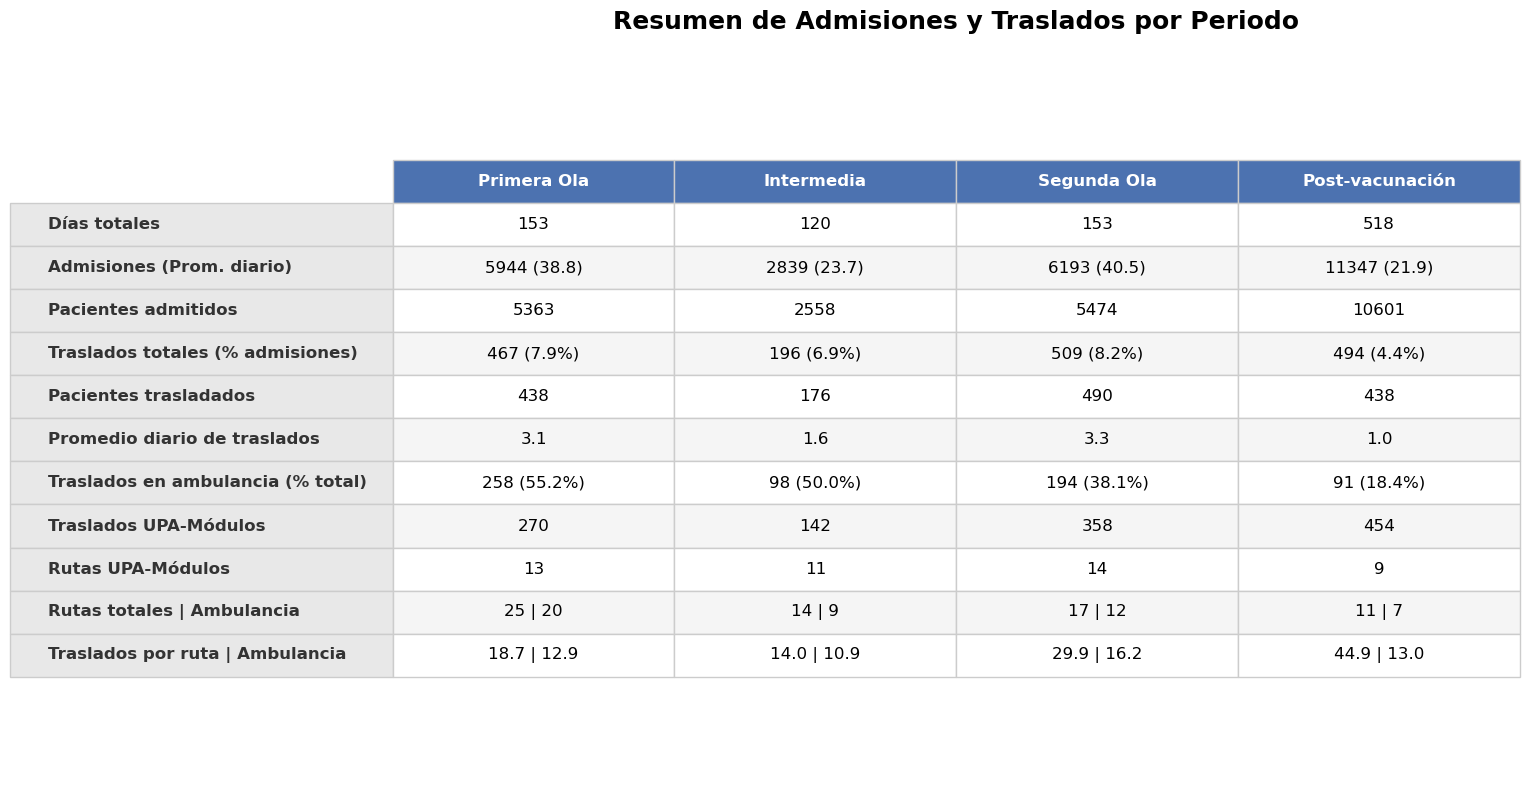

In [9]:
# ==========================================
# EXPORTACIÓN VISUAL DE LA TABLA (MATPLOTLIB)
# ==========================================

# Creamos la figura y ocultamos los ejes clásicos del gráfico
fig, ax = plt.subplots(figsize=(16, 8))
ax.axis('tight')
ax.axis('off')

# Generamos la tabla en Matplotlib
tabla_mpl = ax.table(
    cellText=tabla_resumen.values,
    rowLabels=tabla_resumen.index,
    colLabels=tabla_resumen.columns,
    loc='center',
    cellLoc='center'
)

# --- ESTILIZADO DE LA TABLA ---
# Ajustamos tamaño general de celdas y fuente
tabla_mpl.auto_set_font_size(False)
tabla_mpl.set_fontsize(12)
tabla_mpl.scale(1.2, 2.2)  # (ancho, alto) de las celdas

# Definimos paleta de colores (usamos el azul que ya venís usando)
COLOR_HEADER = '#4c72b0'
COLOR_FILA_PAR = '#f5f5f5'
COLOR_FILA_IMPAR = '#ffffff'
COLOR_INDEX = '#e8e8e8'

# Iteramos por cada celda para pintarla y darle formato
for (row, col), cell in tabla_mpl.get_celld().items():
    cell.set_edgecolor('#cccccc') # Color del borde de las celdas
    
    # Encabezados de columnas (arriba)
    if row == 0:
        cell.set_facecolor(COLOR_HEADER)
        cell.set_text_props(weight='bold', color='white')
    
    # Encabezados de filas (izquierda)
    elif col == -1:
        cell.set_facecolor(COLOR_INDEX)
        cell.set_text_props(weight='bold', color='#333333')
        cell._loc = 'left' # Alineamos el texto a la izquierda para que sea más legible
    
    # Celdas de datos (adentro)
    else:
        # Alternamos colores para efecto cebra
        if row % 2 == 0:
            cell.set_facecolor(COLOR_FILA_PAR)
        else:
            cell.set_facecolor(COLOR_FILA_IMPAR)

# Título de la tabla
plt.title("Resumen de Admisiones y Traslados por Periodo", fontsize=18, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

# Si querés guardarla automáticamente como imagen, descomentá la línea de abajo:
# fig.savefig("tabla_resumen_periodos.png", dpi=300, bbox_inches='tight')

Analizando matrices para el período: Primera Ola (2020-06-01 a 2020-10-31)


C:\Users\micag\AppData\Local\Temp\ipykernel_35572\4144886083.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


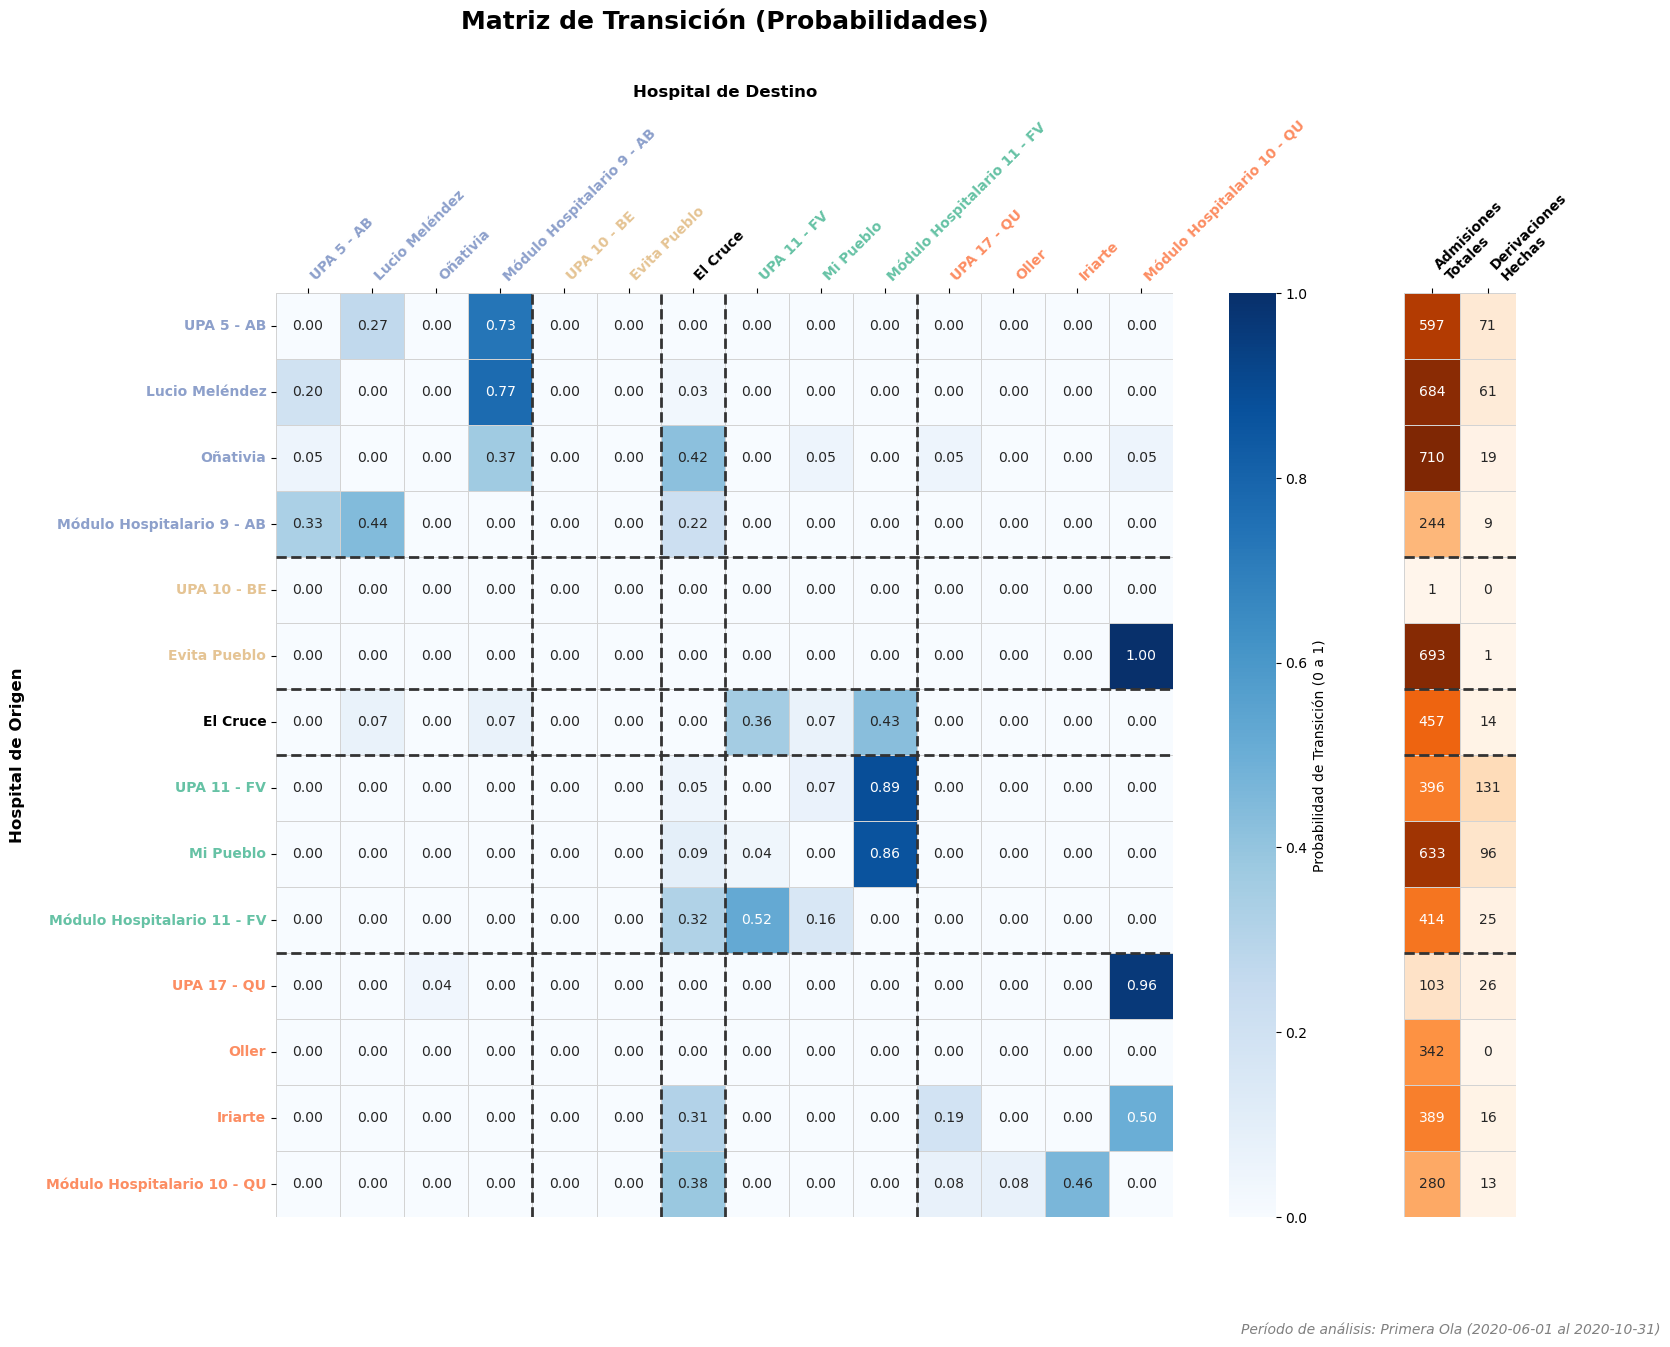

C:\Users\micag\AppData\Local\Temp\ipykernel_35572\4144886083.py:163: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


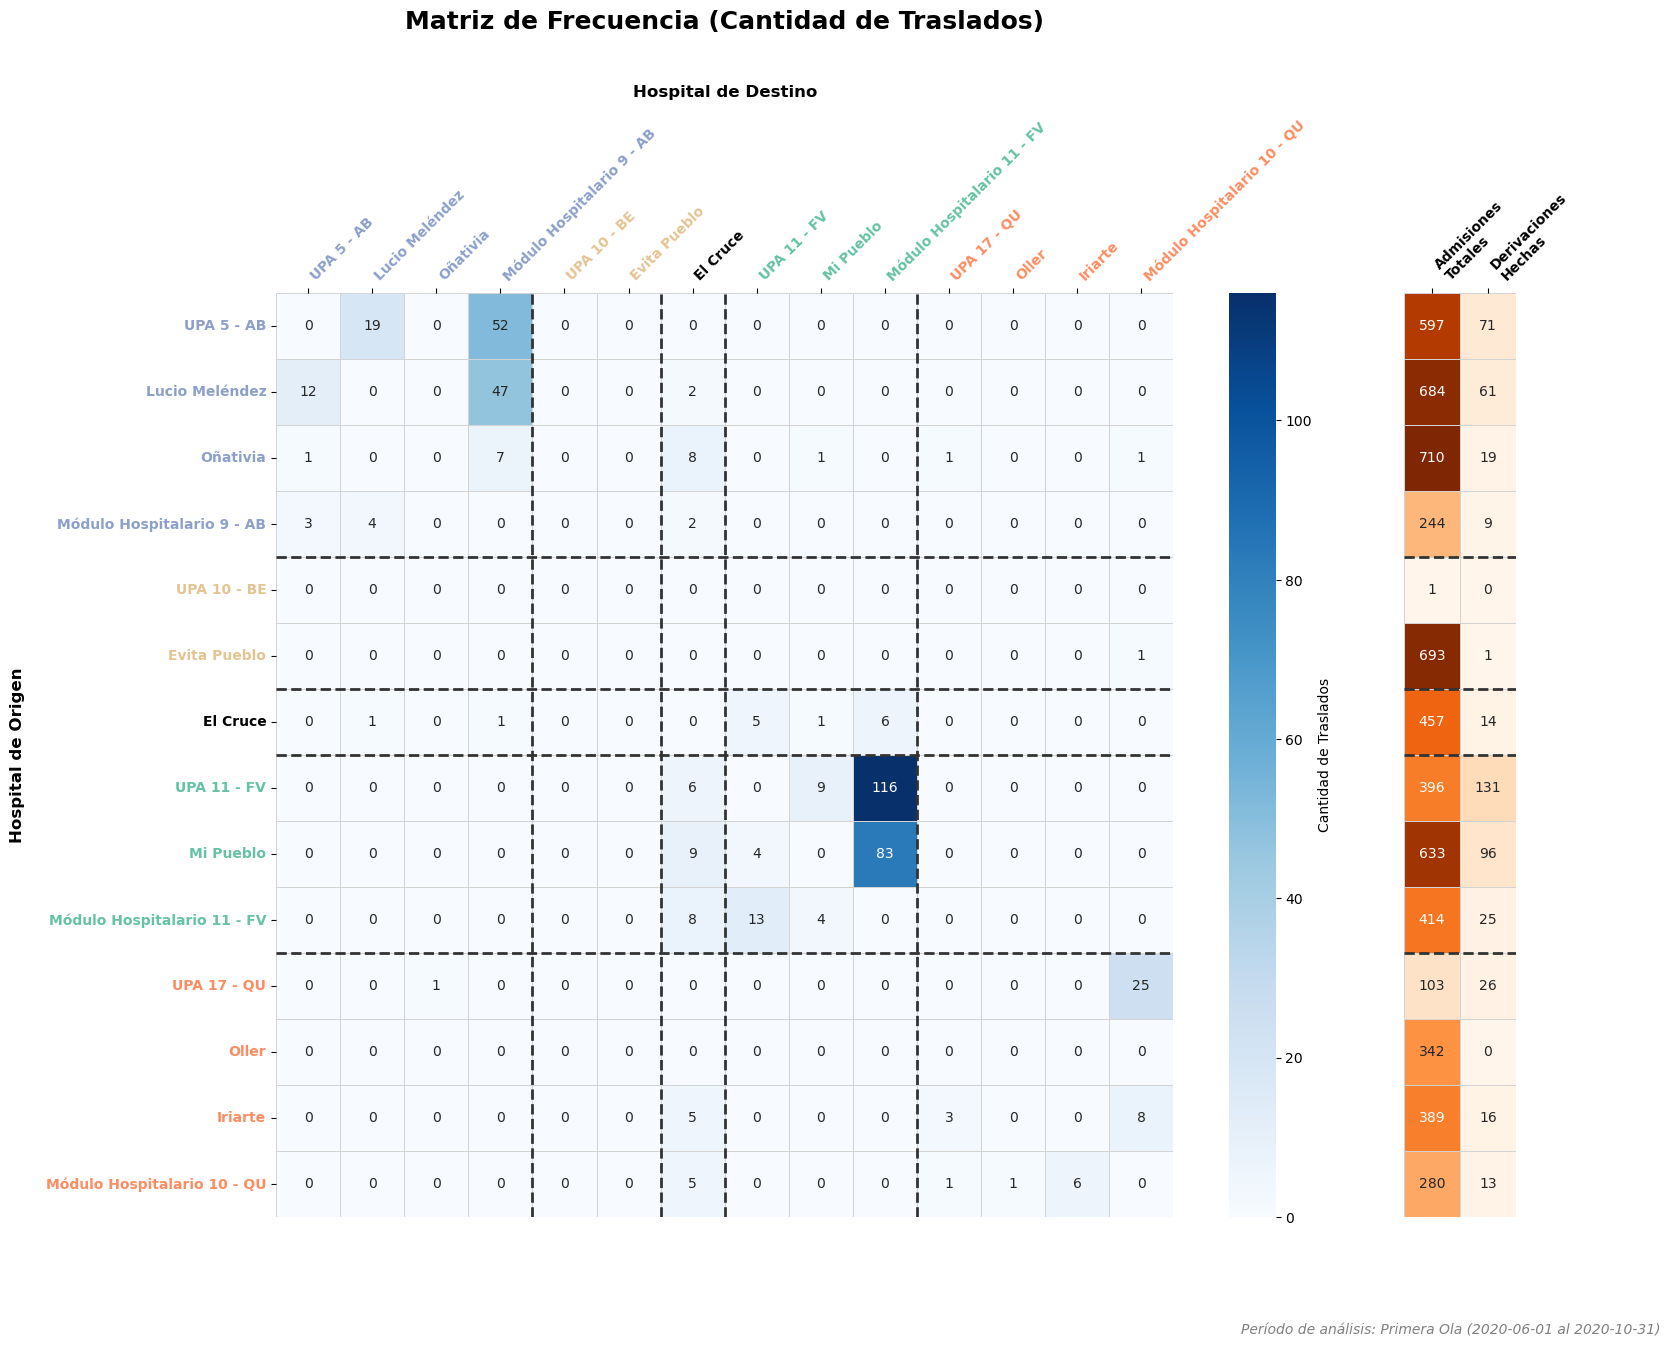

In [10]:
# ==============================================================================
# 8. GENERACIÓN DE MATRICES (PROBABILIDADES Y CANTIDADES) CON TOTALES ADICIONALES
# ==============================================================================



# 1. DEFINICIÓN DEL PERÍODO ESTUDIADO (MODIFICABLE)
# --- Cambiá estas fechas para analizar otros períodos ---
inicio_estudio = '2020-01-01'  
fin_estudio    = '2023-06-30'
# ---------------------------------------------------------
# Usaremos las fechas definidas en la sección 7 para consistencia (ej: las del primer periodo)
if 'periodos' in locals() and len(periodos) > 0:
    inicio_estudio = periodos[0][1] # Tomamos la fecha de inicio del primer periodo
    fin_estudio = periodos[0][2]    # Tomamos la fecha de fin del primer periodo
    titulo_periodo = periodos[0][0] # Tomamos el nombre del periodo (ej: 'Semestre 1')
else:
    # Si no están definidos, usamos fechas por defecto
    inicio_estudio = '2023-01-01'
    fin_estudio = '2023-06-30'
    titulo_periodo = "Período por Defecto"

print(f"Analizando matrices para el período: {titulo_periodo} ({inicio_estudio} a {fin_estudio})")

# Función principal para generar los gráficos
def generar_matrices_traslados(traslados_df, pacientes_df, hospitales_df, fecha_inicio, fecha_fin, tipo_matriz='probabilidad'):
    """
    Genera un heatmap de la matriz de traslados con columnas extras de totales.
    tipo_matriz: 'probabilidad' o 'cantidad'
    """
    
    # -- A. PREPARACIÓN DE METADATA --
    df_meta = hospitales_df[['Nombre Hospital', 'municipioAbreviado', 'complejidad', 'color']].copy()
    df_meta['color'] = df_meta['color'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
    hosp_conocidos_set = set(hospitales_df['Nombre Hospital'])
    df_meta_red = df_meta[df_meta['Nombre Hospital'].isin(hosp_conocidos_set)].copy()

    df_meta_red = df_meta_red.sort_values(['municipioAbreviado', 'complejidad'])

    orden_hospitales = df_meta_red['Nombre Hospital'].tolist()
    municipios_ordenados = df_meta_red['municipioAbreviado'].tolist()
    
    # -- B. FILTRADO DE DATOS POR PERÍODO --
    f_inicio = pd.to_datetime(fecha_inicio)
    f_fin = pd.to_datetime(fecha_fin)
    
    mask_tras = (traslados_df['fecha_egreso'] >= f_inicio) & (traslados_df['fecha_egreso'] <= f_fin)
    df_t_periodo = traslados_df[mask_tras].copy()
    
    mask_validos = (
        (df_t_periodo['hospital_ingreso'].isin(hosp_conocidos_set)) & 
        (df_t_periodo['hospital_destino'].isin(hosp_conocidos_set)) & 
        (df_t_periodo['hospital_ingreso'] != df_t_periodo['hospital_destino'])
    )
    df_t_limpio = df_t_periodo[mask_validos].copy()
    
    df_p_periodo = pacientes_df[(pacientes_df['fecha_ingreso'] >= f_inicio) & (pacientes_df['fecha_ingreso'] <= f_fin)]

    # -- C. CÁLCULO DE DATOS PARA LAS COLUMNAS EXTRAS (TOTALES) --
    
    # 1. Cantidad Total de Admisiones 
    total_admisiones = df_p_periodo.groupby('hospital_origen').size().reindex(orden_hospitales, fill_value=0)
    
    # 2. Cantidad Total de Derivaciones Hechas (Salidas)
    total_derivaciones_hechas = df_t_limpio.groupby('hospital_ingreso').size().reindex(orden_hospitales, fill_value=0)
    
    # 3. Cantidad Total de Derivaciones Recibidas (Entradas)
    total_derivaciones_recibidas = df_t_limpio.groupby('hospital_destino').size().reindex(orden_hospitales, fill_value=0)

    # -- D. CÁLCULO DE LA MATRIZ PRINCIPAL --
    
    matriz_frecuencias = pd.crosstab(
        df_t_limpio['hospital_ingreso'], 
        df_t_limpio['hospital_destino']
    ).reindex(index=orden_hospitales, columns=orden_hospitales, fill_value=0)
    
    if tipo_matriz == 'probabilidad':
        matriz_dibujo = matriz_frecuencias.div(matriz_frecuencias.sum(axis=1), axis=0).fillna(0)
        fmt_matriz = ".2f"
        cmap_matriz = "Blues"
        label_colorbar = 'Probabilidad de Transición (0 a 1)'
        titulo_base = "Matriz de Transición (Probabilidades)"
    else:
        matriz_dibujo = matriz_frecuencias
        fmt_matriz = "d" 
        cmap_matriz = "Blues" 
        label_colorbar = 'Cantidad de Traslados'
        titulo_base = "Matriz de Frecuencia (Cantidad de Traslados)"

    # -- E. DIBUJO CON SUBPLOTS (SEABORN + GRIDSPEC) --
    
    fig = plt.figure(figsize=(16, 12))
    fig.patch.set_facecolor('white')
    
    # Ajustamos el ancho para que queden bien las 2 columnas extras
    gs = gridspec.GridSpec(1, 2, width_ratios=[12, 1.2], wspace=0.01) 

    ax_matriz = plt.subplot(gs[0])
    ax_totales = plt.subplot(gs[1])

    sns.heatmap(matriz_dibujo, annot=True, cmap=cmap_matriz, fmt=fmt_matriz, 
                linewidths=0.5, linecolor='lightgray', 
                cbar_kws={'label': label_colorbar}, ax=ax_matriz)

    # =========================================================================
    # ACÁ ESTÁ LA ELECCIÓN DE COLUMNAS. DESCOMENTAMOS LA QUE QUERRAMOS USAR.
    # por ahora dejé "realizadas"
    # =========================================================================
    df_totales_plot = pd.DataFrame({
        'Admisiones\nTotales': total_admisiones.values,
        'Derivaciones\nHechas': total_derivaciones_hechas.values,
        # 'Derivaciones\nRecibidas': total_derivaciones_recibidas.values,
    }, index=orden_hospitales)
    
    sns.heatmap(df_totales_plot, annot=True, cmap="Oranges", fmt="d", 
                linewidths=0.5, linecolor='lightgray',
                cbar=False, 
                ax=ax_totales)

    # -- F. CONFIGURACIÓN ESTÉTICA Y EJE X ARRIBA --
    
    ax_matriz.xaxis.tick_top() 
    ax_matriz.xaxis.set_label_position('top') 
    
    ax_matriz.set_title(f"{titulo_base}", fontsize=18, fontweight='bold', pad=40)
    ax_matriz.set_xlabel("Hospital de Destino", fontsize=12, fontweight='bold', labelpad=15)
    ax_matriz.set_ylabel("Hospital de Origen", fontsize=12, fontweight='bold', labelpad=15)

    ax_totales.xaxis.tick_top() 
    ax_totales.xaxis.set_label_position('top')
    ax_totales.set_ylabel("") 
    
    dict_colores = dict(zip(df_meta_red['Nombre Hospital'], df_meta_red['color']))

    for tick_label in ax_matriz.get_xticklabels():
        hosp_name = tick_label.get_text()
        tick_label.set_color(dict_colores.get(hosp_name, 'black'))
        tick_label.set_fontweight('bold')
        tick_label.set_rotation(45)
        tick_label.set_ha('left') 

    for tick_label in ax_matriz.get_yticklabels():
        hosp_name = tick_label.get_text()
        tick_label.set_color(dict_colores.get(hosp_name, 'black'))
        tick_label.set_fontweight('bold')

    for tick_label in ax_totales.get_xticklabels():
        tick_label.set_fontweight('bold')
        tick_label.set_rotation(45)
        tick_label.set_ha('left') 

    ax_totales.set_yticklabels([])
    ax_totales.tick_params(axis='y', which='both', length=0) 

    cambios_municipio = [i for i in range(1, len(municipios_ordenados)) 
                         if municipios_ordenados[i] != municipios_ordenados[i-1]]

    for c in cambios_municipio:
        ax_matriz.axhline(c, color='#333333', lw=2, linestyle='--') 
        ax_totales.axhline(c, color='#333333', lw=2, linestyle='--')
        ax_matriz.axvline(c, color='#333333', lw=2, linestyle='--') 

    plt.tight_layout()

    # =========================================================================
    # LEYENDA DEL PERÍODO ABAJO A LA DERECHA
    # =========================================================================
    texto_leyenda = f"Período de análisis: {titulo_periodo} ({fecha_inicio} al {fecha_fin})"
    plt.figtext(0.99, 0.01, texto_leyenda, horizontalalignment='right', 
                verticalalignment='bottom', fontsize=10, color='gray', style='italic')


    plt.show()

# ==========================================
# G. LLAMADAS PARA GENERAR LOS 2 GRÁFICOS
# ==========================================

generar_matrices_traslados(df_traslados, pacientes, hospitales, inicio_estudio, fin_estudio, tipo_matriz='probabilidad')

generar_matrices_traslados(df_traslados, pacientes, hospitales, inicio_estudio, fin_estudio, tipo_matriz='cantidad')


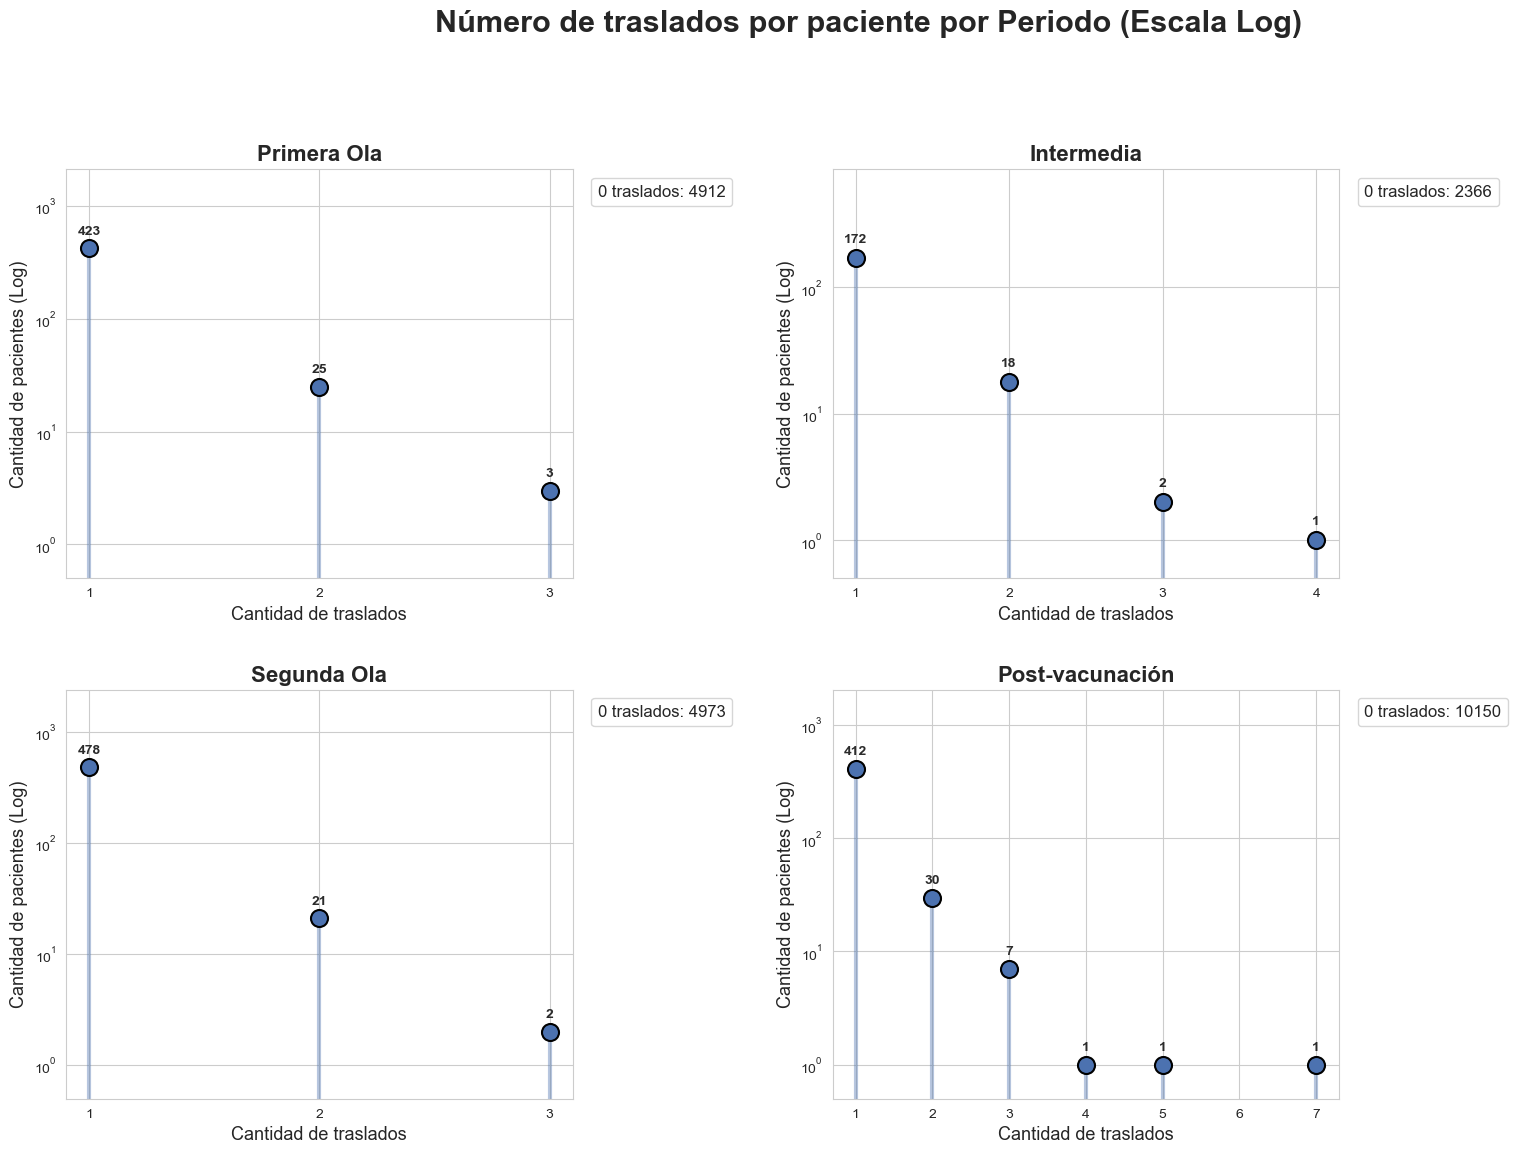

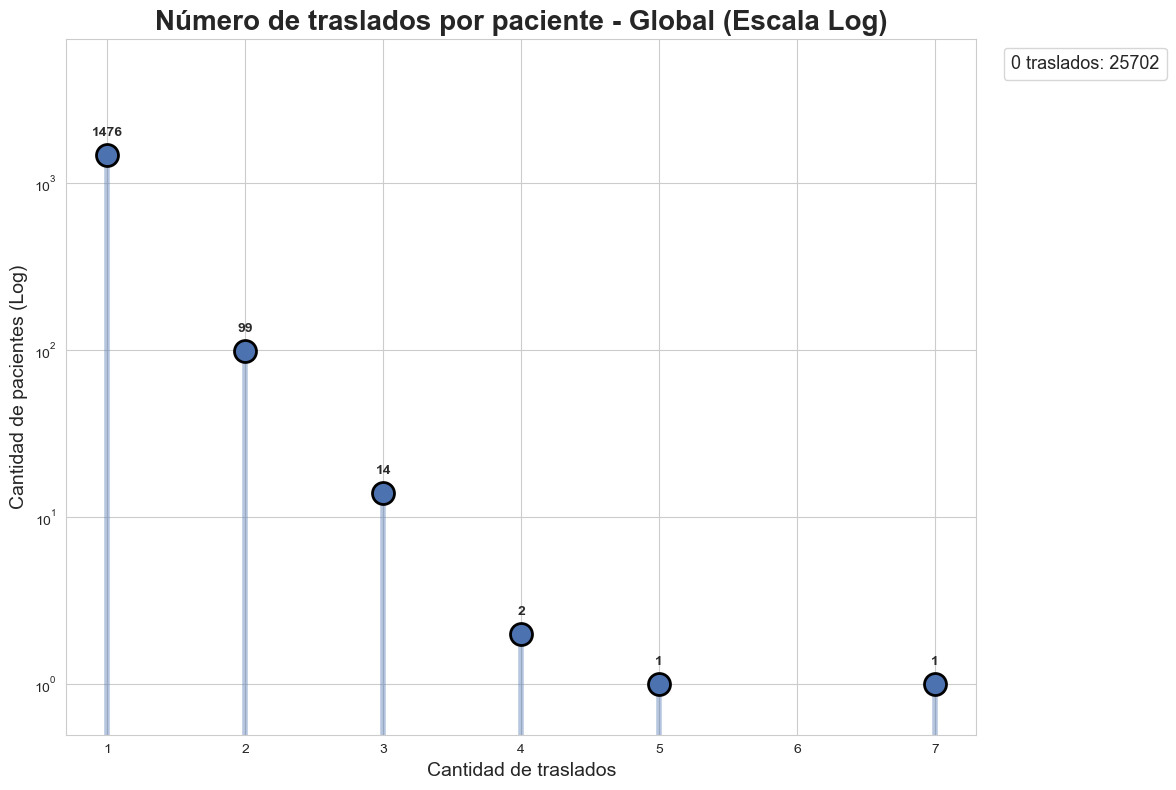

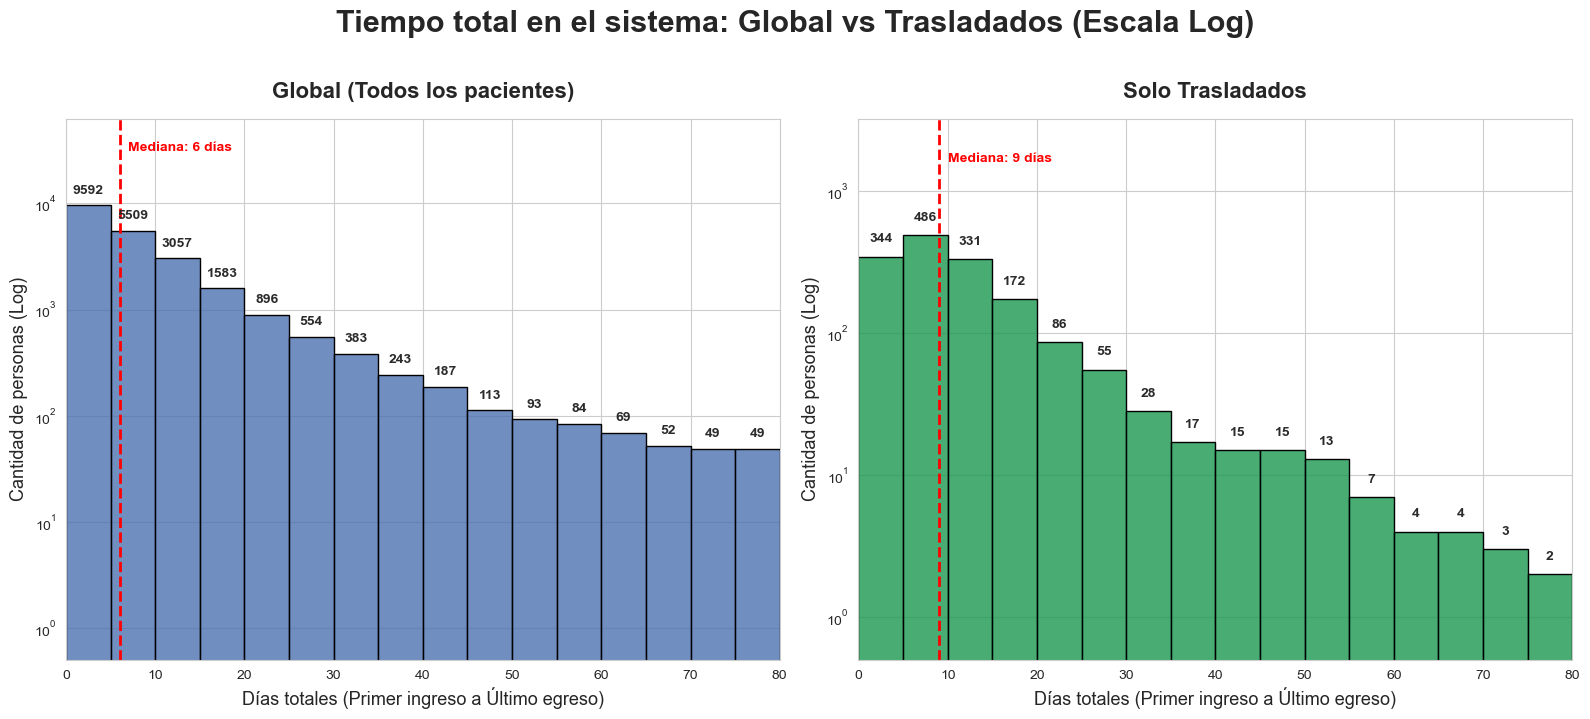

In [11]:
# ==========================================
# 9. ANÁLISIS ESTADÍSTICO Y TEMPORAL
# ==========================================


# --- 1. LIMPIEZA BASE PARA SINCRONIZAR CON LA TABLA/GRAFO ---
mask_validos_stats = (
    (df_traslados['hospital_ingreso'].isin(hospitales_conocidos)) & 
    (df_traslados['hospital_destino'].isin(hospitales_conocidos)) & 
    (df_traslados['hospital_ingreso'] != df_traslados['hospital_destino'])
)
df_traslados_stats = df_traslados[mask_validos_stats].copy()

# --- CONFIGURACIÓN DE ESTILO ---
sns.set_style("whitegrid") 

COLOR_AZUL = '#4c72b0' 
COLOR_VERDE = '#1a9850'

# --- 2 FUNCIONES DE ANOTACIÓN ---

def agregar_valores_scatter(ax, x_vals, y_vals):
    max_y = max(y_vals) if len(y_vals) > 0 else 1
    
    for x, y in zip(x_vals, y_vals):
        if y > 0: 
            y_texto = y * 1.25 # Un poco más de espacio para que no toque el borde del punto
            ax.text(x, y_texto, f'{int(y)}',
                    ha="center", va="bottom", fontsize=10, fontweight='bold', color='#2b2b2b')
            
    ax.set_ylim(0.5, max_y * 5) # Límite inferior 0.5 para la escala logarítmica

def agregar_valores_barras(ax):
    max_y = ax.get_ylim()[1]
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0: 
            y_pos = p.get_y() + height
            y_texto = y_pos * 1.2 
            ax.text(p.get_x() + p.get_width() / 2., y_texto, f'{int(height)}',
                    ha="center", va="bottom", fontsize=10, fontweight='bold', color='#2b2b2b')
            
    ax.set_ylim(0.5, max_y * 5) 

# =========================================================================
# GRÁFICO 1: NÚMERO DE TRASLADOS POR PACIENTE (LOLLIPOP CHART)
# =========================================================================
fig1a, axes1a = plt.subplots(2, 2, figsize=(18, 12))
fig1a.patch.set_facecolor('white')
fig1a.suptitle("Número de traslados por paciente por Periodo (Escala Log)", fontsize=22, fontweight='bold', y=0.98)
axes1a_flat = axes1a.flatten()

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes1a_flat[idx]
    
    mask_p = (pacientes['fecha_ingreso'] >= inicio) & (pacientes['fecha_ingreso'] <= fin)
    mask_t = (df_traslados_stats['fecha_egreso'] >= inicio) & (df_traslados_stats['fecha_egreso'] <= fin)
    df_t_per = df_traslados_stats[mask_t]
    
    pacientes_admitidos_per = set(pacientes[mask_p]['paciente_id'])
    pacientes_trasladados_per = set(df_t_per['paciente_id'])
    cero_traslados = len(pacientes_admitidos_per - pacientes_trasladados_per)
    
    if not df_t_per.empty:
        conteo = df_t_per.groupby('paciente_id').size().value_counts().sort_index()
        
        # 1. ESTÉTICA: Dibujar líneas verticales (el "palito" de la piruleta)
        # El ymin es 0.5 porque estamos en escala logarítmica (no puede ser 0)
        ax.vlines(x=conteo.index, ymin=0.5, ymax=conteo.values, color=COLOR_AZUL, alpha=0.4, linewidth=3, zorder=2)
        
        # 2. ESTÉTICA: Dibujar los puntos encima con un borde negro para que resalten
        sns.scatterplot(x=conteo.index, y=conteo.values, color=COLOR_AZUL, 
                        s=150, edgecolor='black', linewidth=1.5, ax=ax, zorder=3)
        
        ax.set_yscale('log') 
        agregar_valores_scatter(ax, conteo.index, conteo.values)
        
    ax.set_title(titulo, fontsize=16, fontweight='bold')
    ax.set_xlabel("Cantidad de traslados", fontsize=13)
    ax.set_ylabel("Cantidad de pacientes (Log)", fontsize=13)
    ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True)) 
    
    leyenda_0 = mlines.Line2D([], [], color='none', marker='None', label=f'0 traslados: {cero_traslados}')
    ax.legend(handles=[leyenda_0], loc='upper left', bbox_to_anchor=(1.02, 1), 
              frameon=True, fontsize=12, handlelength=0, handletextpad=0)

plt.tight_layout(rect=[0, 0, 0.88, 0.96], pad=3.0)

# FIGURA 1B: GLOBAL (1 GRANDE) - LOLLIPOP CHART
fig1b, ax1b = plt.subplots(figsize=(14, 8))
fig1b.patch.set_facecolor('white')

conteo_global = df_traslados_stats.groupby('paciente_id').size().value_counts().sort_index()

# 1. ESTÉTICA: Dibujar líneas verticales
ax1b.vlines(x=conteo_global.index, ymin=0.5, ymax=conteo_global.values, color=COLOR_AZUL, alpha=0.4, linewidth=4, zorder=2)

# 2. ESTÉTICA: Dibujar los puntos grandes con borde
sns.scatterplot(x=conteo_global.index, y=conteo_global.values, color=COLOR_AZUL, 
                s=250, edgecolor='black', linewidth=2, ax=ax1b, zorder=3)

ax1b.set_yscale('log')
agregar_valores_scatter(ax1b, conteo_global.index, conteo_global.values)

ax1b.set_title("Número de traslados por paciente - Global (Escala Log)", fontsize=20, fontweight='bold')
ax1b.set_xlabel("Cantidad de traslados", fontsize=14)
ax1b.set_ylabel("Cantidad de pacientes (Log)", fontsize=14)
ax1b.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

pacientes_admitidos_global = set(pacientes['paciente_id'])
pacientes_trasladados_global = set(df_traslados_stats['paciente_id'])
cero_traslados_global = len(pacientes_admitidos_global - pacientes_trasladados_global)

leyenda_0_global = mlines.Line2D([], [], color='none', marker='None', label=f'0 traslados: {cero_traslados_global}')
ax1b.legend(handles=[leyenda_0_global], loc='upper left', bbox_to_anchor=(1.02, 1), 
            frameon=True, fontsize=13, handlelength=0, handletextpad=0)

plt.tight_layout(rect=[0, 0, 0.85, 1])

# =========================================================================
# GRÁFICO 2: TIEMPO EN EL SISTEMA HOSPITALARIO (GLOBAL VS TRASLADADOS)
# =========================================================================
tiempo_trayectorias_todas = pacientes.groupby('paciente_id').agg(
    ingreso_sistema=('fecha_ingreso', 'min'),
    egreso_sistema=('fecha_egreso', 'max')
)
tiempo_trayectorias_todas['dias_en_sistema'] = (tiempo_trayectorias_todas['egreso_sistema'] - tiempo_trayectorias_todas['ingreso_sistema']).dt.days
tiempo_trayectorias_todas = tiempo_trayectorias_todas[tiempo_trayectorias_todas['dias_en_sistema'] >= 0].copy()

ids_trasladados = set(df_traslados_stats['paciente_id'])
mask_trasladados = tiempo_trayectorias_todas.index.isin(ids_trasladados)

df_trasladados = tiempo_trayectorias_todas[mask_trasladados]

if not tiempo_trayectorias_todas.empty:
    limite_p99_global = tiempo_trayectorias_todas['dias_en_sistema'].quantile(0.99)
    max_plot = int(limite_p99_global) if not pd.isna(limite_p99_global) else int(tiempo_trayectorias_todas['dias_en_sistema'].max())
    bins_5dias = np.arange(0, max_plot + 5, 5)

    fig2, axes2 = plt.subplots(1, 2, figsize=(16, 7))
    fig2.patch.set_facecolor('white')
    fig2.suptitle("Tiempo total en el sistema: Global vs Trasladados (Escala Log)", fontsize=22, fontweight='bold', y=1.02)

    paneles = [
        ("Global (Todos los pacientes)", tiempo_trayectorias_todas, COLOR_AZUL),
        ("Solo Trasladados", df_trasladados, COLOR_VERDE)
    ]

    for ax, (titulo, df_subset, color) in zip(axes2, paneles):
        sns.histplot(df_subset['dias_en_sistema'], bins=bins_5dias, color=color, 
                     ax=ax, edgecolor='black', alpha=0.8)
        
        ax.set_yscale('log')
        agregar_valores_barras(ax)

        ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)
        ax.set_xlabel("Días totales (Primer ingreso a Último egreso)", fontsize=13)
        ax.set_ylabel("Cantidad de personas (Log)", fontsize=13)
        ax.set_xlim(0, max_plot)
        ax.set_xticks(np.arange(0, max_plot + 5, 10))
        
        mediana = df_subset['dias_en_sistema'].median()
        if not pd.isna(mediana):
            ax.axvline(mediana, color='red', linestyle='dashed', linewidth=2)
            ax.text(mediana + 1, ax.get_ylim()[1]*0.5, f'Mediana: {int(mediana)} días', color='red', fontweight='bold')

    plt.tight_layout()
    plt.show()

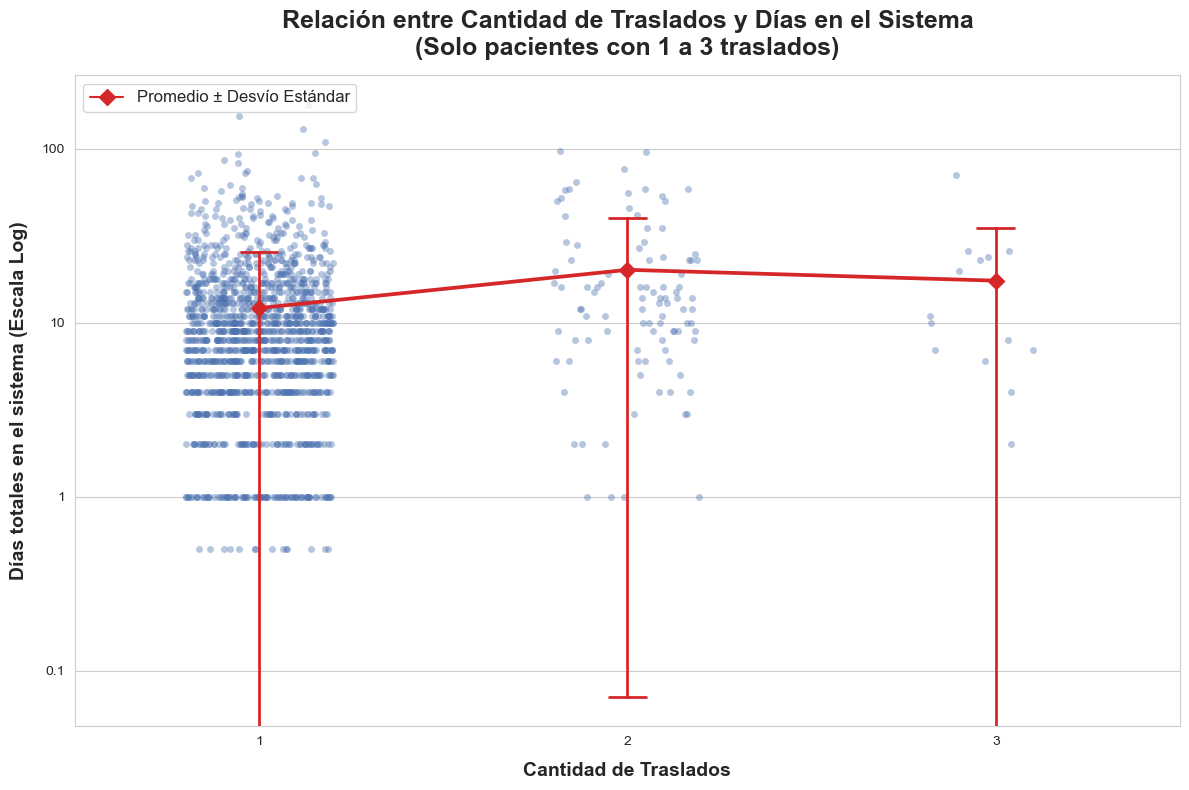

In [12]:
import numpy as np

# =========================================================================
# GRÁFICO 3: SCATTER DE TRASLADOS VS TIEMPO (< 4 TRASLADOS)
# =========================================================================

# 1. Unificar los datos: Contamos traslados y cruzamos con el tiempo en sistema
conteo_por_paciente = df_traslados_stats.groupby('paciente_id').size().reset_index(name='cantidad_traslados')
df_cruce = pd.merge(tiempo_trayectorias_todas, conteo_por_paciente, on='paciente_id', how='inner')

# 2. Aplicar filtros solicitados: Menos de 4 traslados (es decir, 1, 2 o 3)
mask_filtro = df_cruce['cantidad_traslados'] < 4
df_plot = df_cruce[mask_filtro].copy()

# 3. Ajuste para escala logarítmica: Reemplazamos los 0 días por 0.5 visualmente
df_plot['dias_plot'] = df_plot['dias_en_sistema'].replace(0, 0.5)

# 4. Crear la figura
fig3, ax3 = plt.subplots(figsize=(12, 8))
fig3.patch.set_facecolor('white')

# 5. DIBUJAR LA NUBE DE PUNTOS (Jittered Scatter)
# jitter=0.2 dispersa un poco los puntos horizontalmente para que no se pisen entre sí
sns.stripplot(
    data=df_plot, 
    x='cantidad_traslados', 
    y='dias_plot', 
    color=COLOR_AZUL, 
    alpha=0.4,       # Semitransparente para ver densidades
    jitter=0.2, 
    size=5,          # Tamaño del punto
    ax=ax3,
    zorder=1
)

# 6. DIBUJAR EL PROMEDIO Y DESVÍO ESTÁNDAR POR ENCIMA
# errorbar='sd' le dice a Seaborn que grafique el Desvío Estándar (Standard Deviation)
sns.pointplot(
    data=df_plot, 
    x='cantidad_traslados', 
    y='dias_plot', 
    estimator=np.mean, 
    errorbar='sd',    # Nota: Si usas una versión muy vieja de Seaborn, cambia esto por ci='sd'
    color='#d62728',  # Rojo para que resalte
    markers='D',      # Diamante para el promedio
    capsize=0.1,      # Sombreritos en las barras de error
    err_kws={'linewidth': 2}, # Grosor de la línea del desvío
    ax=ax3,
    zorder=3
)

# 7. ESTÉTICA Y ESCALA LOGARÍTMICA
ax3.set_yscale('log')

# Formatear etiquetas de los ejes para que el logaritmo sea fácil de leer
from matplotlib.ticker import FuncFormatter
ax3.yaxis.set_major_formatter(FuncFormatter(lambda y, _: '{:g}'.format(y)))

ax3.set_title("Relación entre Cantidad de Traslados y Días en el Sistema\n(Solo pacientes con 1 a 3 traslados)", 
              fontsize=18, fontweight='bold', pad=15)
ax3.set_xlabel("Cantidad de Traslados", fontsize=14, fontweight='bold', labelpad=10)
ax3.set_ylabel("Días totales en el sistema (Escala Log)", fontsize=14, fontweight='bold', labelpad=10)

# Leyenda manual para explicar el punto rojo
leyenda_stats = mlines.Line2D([], [], color='#d62728', marker='D', markersize=8, 
                              label='Promedio ± Desvío Estándar')
ax3.legend(handles=[leyenda_stats], loc='upper left', frameon=True, fontsize=12)

plt.tight_layout()
plt.show()

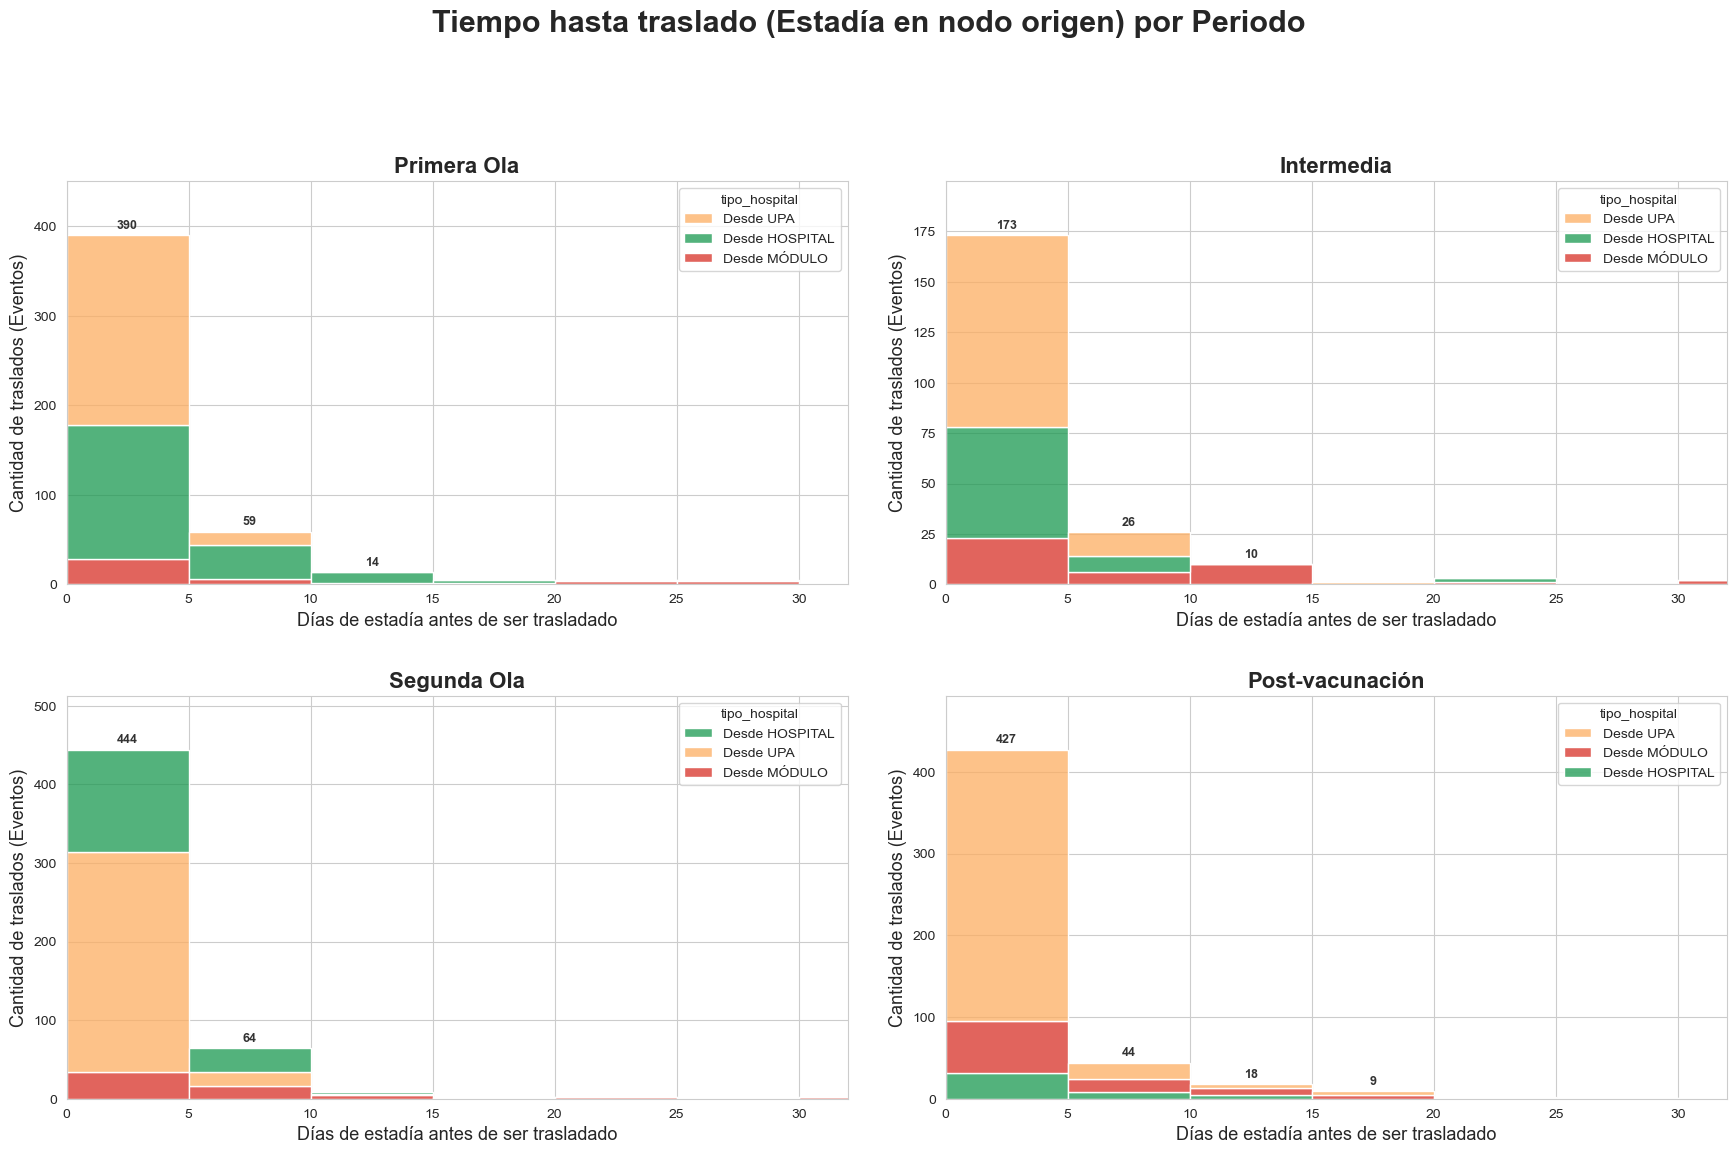

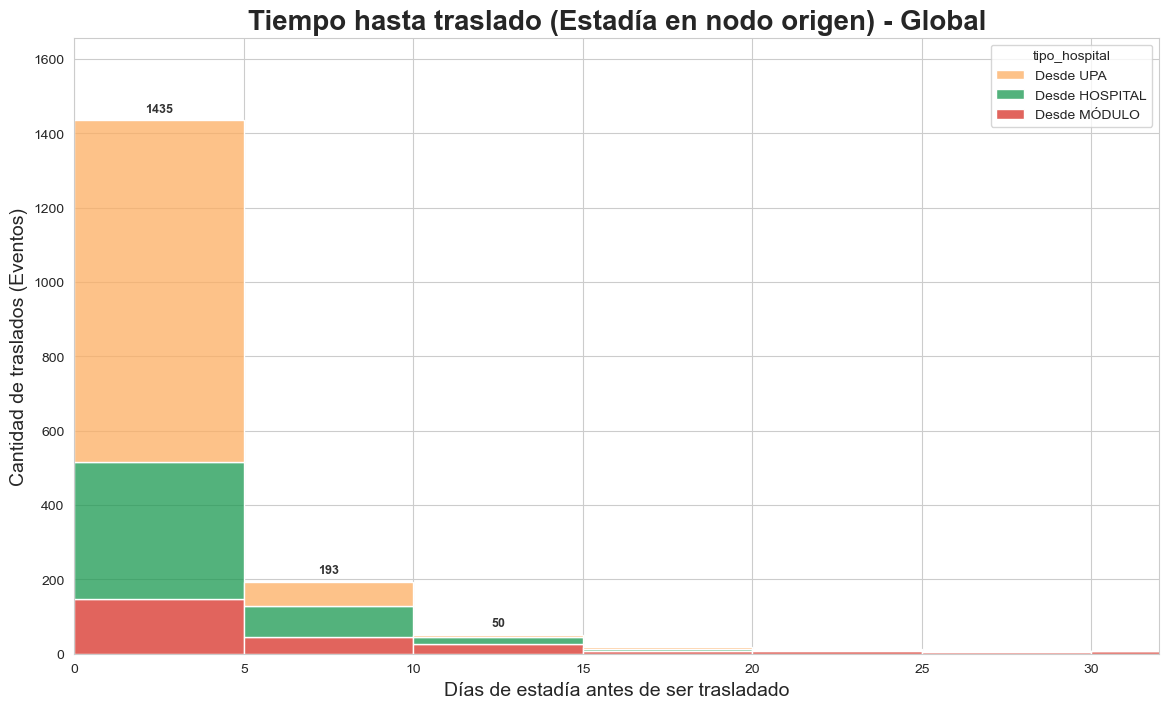

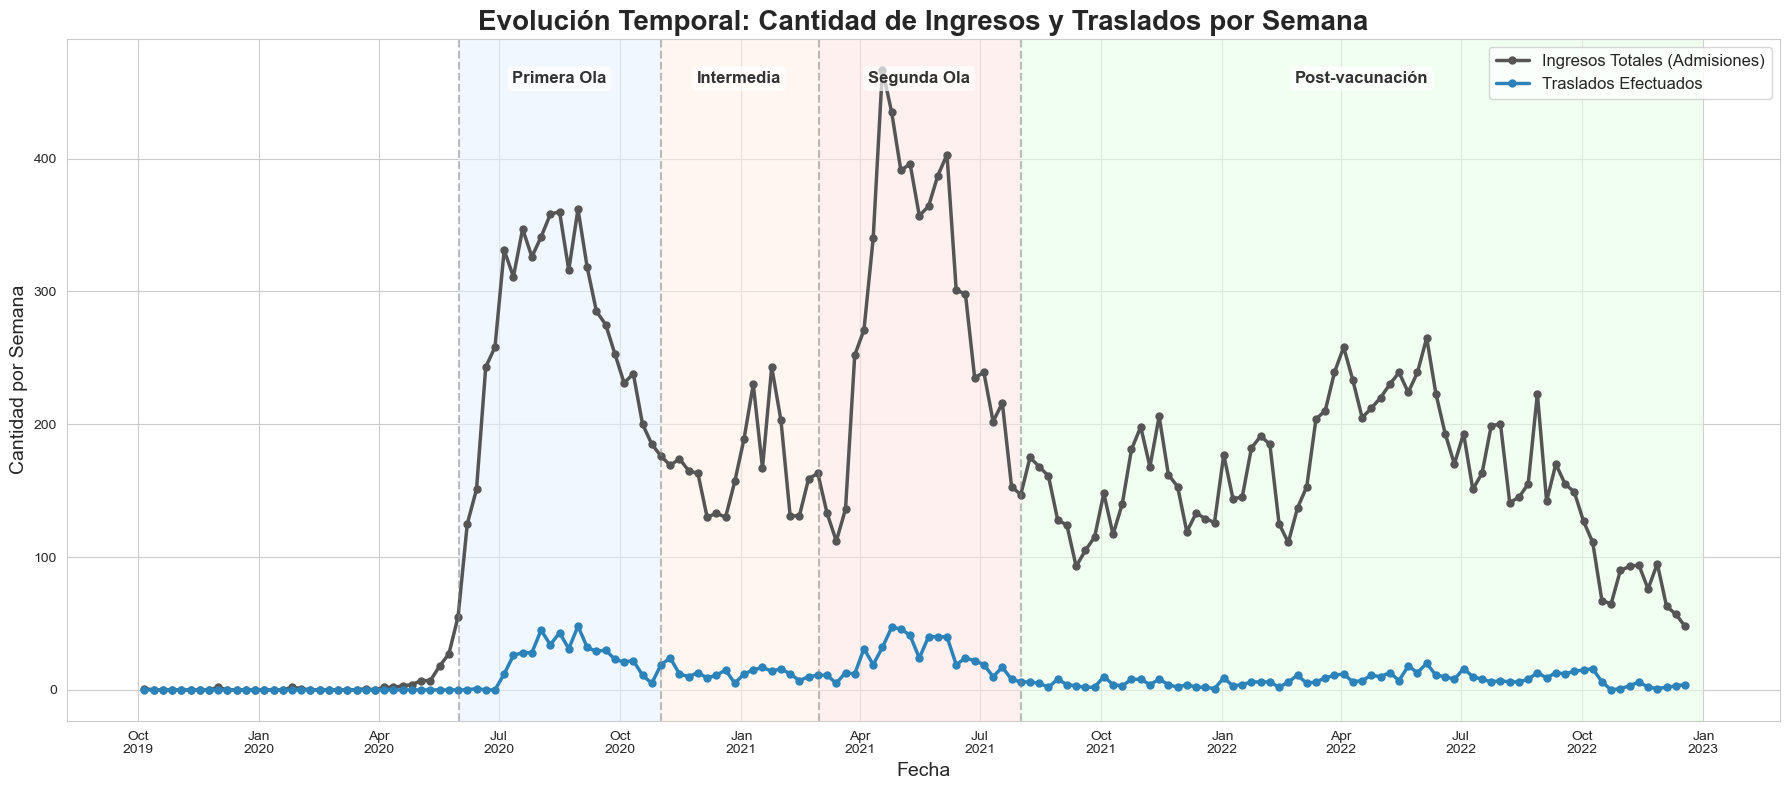

In [13]:

# --- CONFIGURACIÓN DE COLORES ---
COLOR_INGRESOS = '#555555' 
COLOR_TRASLADOS = '#2b83ba' 

colores_tipo_origen = {
    'Desde MÓDULO': '#d73027', 
    'Desde UPA': '#fdae61', 
    'Desde HOSPITAL': '#1a9850'
}

# --- NUEVA FUNCIÓN PARA BARRAS APILADAS (SOLO TOTALES) ---
def agregar_valores_totales(ax):
    max_y_per_x = {}
    # 1. Encontramos el techo (la altura total) para cada posición en el eje X
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            x_center = p.get_x() + p.get_width() / 2.
            y_top = p.get_y() + height
            
            # Guardamos el punto más alto de la pila para esa coordenada X
            if x_center not in max_y_per_x or y_top > max_y_per_x[x_center]:
                max_y_per_x[x_center] = y_top

    # 2. Dibujamos un solo texto en la cima de cada barra
    max_y_axis = ax.get_ylim()[1]
    space = max_y_axis * 0.01 
    
    for x_center, total_height in max_y_per_x.items():
        if total_height >= (max_y_axis * 0.02): # Filtro para no ensuciar con barras casi invisibles
            ax.text(x_center, total_height + space,
                    f'{int(total_height)}',
                    ha="center", va="bottom", fontsize=9, fontweight='bold', color='#333333')
            
    ax.set_ylim(0, max_y_axis * 1.1)

# =========================================================================
# GRÁFICO 3: TIEMPO HASTA TRASLADO (DÍAS EN EL NODO ORIGEN)
# =========================================================================
df_movimientos = df_traslados_stats.copy()
df_movimientos['dias_antes_traslado'] = (df_movimientos['fecha_egreso'] - df_movimientos['fecha_ingreso']).dt.days

# Filtramos posibles errores de carga (fechas negativas)
df_movimientos = df_movimientos[df_movimientos['dias_antes_traslado'] >= 0]

def clasificar_hospital(nombre):
    nombre_norm = str(nombre).upper()
    if 'MODULO' in nombre_norm or 'MÓDULO' in nombre_norm: return 'Desde MÓDULO'
    elif 'UPA' in nombre_norm: return 'Desde UPA'
    else: return 'Desde HOSPITAL'

df_movimientos['tipo_hospital'] = df_movimientos['hospital_ingreso'].apply(clasificar_hospital)

# Calculamos límite para el eje X
if not df_movimientos.empty:
    limite_p99_nodo = df_movimientos['dias_antes_traslado'].quantile(0.99)
    max_plot_nodo = int(limite_p99_nodo) if not pd.isna(limite_p99_nodo) else int(df_movimientos['dias_antes_traslado'].max())
    bins_mov_5 = np.arange(0, max_plot_nodo + 5, 5)
else:
    max_plot_nodo = 30
    bins_mov_5 = np.arange(0, 35, 5)

# FIGURA 3A: PERIODOS (2x2)
fig3a, axes3a = plt.subplots(2, 2, figsize=(18, 12))
fig3a.patch.set_facecolor('white')
fig3a.suptitle("Tiempo hasta traslado (Estadía en nodo origen) por Periodo", fontsize=22, fontweight='bold', y=0.98)
axes3a_flat = axes3a.flatten()

for idx, (titulo, inicio, fin) in enumerate(periodos):
    ax = axes3a_flat[idx]
    
    mask_m = (df_movimientos['fecha_egreso'] >= inicio) & (df_movimientos['fecha_egreso'] <= fin)
    df_m_per = df_movimientos[mask_m]
    
    if not df_m_per.empty:
        sns.histplot(data=df_m_per, x='dias_antes_traslado', hue='tipo_hospital', 
                     palette=colores_tipo_origen, multiple='stack', bins=bins_mov_5, 
                     ax=ax, edgecolor='white')
        
        # Usamos la función nueva acá
        agregar_valores_totales(ax)
        
    ax.set_title(titulo, fontsize=16, fontweight='bold')
    ax.set_xlabel("Días de estadía antes de ser trasladado", fontsize=13)
    ax.set_ylabel("Cantidad de traslados (Eventos)", fontsize=13)
    ax.set_xlim(0, max_plot_nodo)

plt.tight_layout(rect=[0, 0, 1, 0.95], pad=3.0)

# FIGURA 3B: GLOBAL (1 GRANDE)
fig3b, ax3b = plt.subplots(figsize=(14, 8))
fig3b.patch.set_facecolor('white')

if not df_movimientos.empty:
    sns.histplot(data=df_movimientos, x='dias_antes_traslado', hue='tipo_hospital', 
                 palette=colores_tipo_origen, multiple='stack', bins=bins_mov_5, 
                 ax=ax3b, edgecolor='white')

    # Y usamos la función nueva acá
    agregar_valores_totales(ax3b)

ax3b.set_title("Tiempo hasta traslado (Estadía en nodo origen) - Global", fontsize=20, fontweight='bold')
ax3b.set_xlabel("Días de estadía antes de ser trasladado", fontsize=14)
ax3b.set_ylabel("Cantidad de traslados (Eventos)", fontsize=14)
ax3b.set_xlim(0, max_plot_nodo)


# =========================================================================
# GRÁFICO 4: EVOLUCIÓN TEMPORAL
# =========================================================================
fig4, ax4 = plt.subplots(figsize=(18, 8))
fig4.patch.set_facecolor('white')

ingresos_ts = pacientes.set_index('fecha_ingreso').resample('W').size().rename('Ingresos Totales')
traslados_ts = df_traslados_stats.set_index('fecha_egreso').resample('W').size().rename('Traslados')
df_ts = pd.concat([ingresos_ts, traslados_ts], axis=1).fillna(0)

# Graficamos las líneas (por semana)
ax4.plot(df_ts.index, df_ts['Ingresos Totales'], label='Ingresos Totales (Admisiones)', 
         color=COLOR_INGRESOS, linewidth=2.5, marker='o', markersize=5)
ax4.plot(df_ts.index, df_ts['Traslados'], label='Traslados Efectuados', 
         color=COLOR_TRASLADOS, linewidth=2.5, marker='o', markersize=5)

# Dibujamos las franjas de fondo para identificar las etapas
colores_fondo = ['#e6f2ff', '#fff0e6', '#ffe6e6', '#e6ffe6'] 
for i, (titulo, inicio, fin) in enumerate(periodos):
    f_ini = pd.to_datetime(inicio)
    f_fin = pd.to_datetime(fin)
    
    ax4.axvspan(f_ini, f_fin, color=colores_fondo[i % len(colores_fondo)], alpha=0.6)
    ax4.axvline(f_ini, color='gray', linestyle='--', alpha=0.5)
    
    y_max = ax4.get_ylim()[1]
    mid_point = f_ini + (f_fin - f_ini) / 2
    ax4.text(mid_point, y_max * 0.95, titulo, ha='center', va='top', 
             fontsize=12, fontweight='bold', color='#333333',
             bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.3'))

ax4.set_title("Evolución Temporal: Cantidad de Ingresos y Traslados por Semana", fontsize=20, fontweight='bold')
ax4.set_xlabel("Fecha", fontsize=14)
ax4.set_ylabel("Cantidad por Semana", fontsize=14)

ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%b\n%Y'))

ax4.legend(loc='upper right', fontsize=12, frameon=True)
plt.tight_layout()

plt.show()

In [14]:
# ==========================================
# 10. CONSULTAS, FILTROS Y EXTRACCIÓN DE DATOS
# ==========================================

# ---------------------------------------------------------
# 1, 2 y 3. ACCESO A LOS DATAFRAMES PRINCIPALES
# ---------------------------------------------------------
# Simplemente llamando a estas variables ya tenés tus dataframes listos:
df_pacientes_final = pacientes.copy()        # 1. DF normal (historial completo)
df_eventos_traslados = df_traslados.copy()   # 2. DF de traslados (solo los eventos puente)
df_trayectorias_final = df_trayectoria.copy()# 3. DF de trayectorias (1 fila por persona)

# ---------------------------------------------------------
# 4. CÓMO FILTRAR (Ejemplos útiles)
# ---------------------------------------------------------
# A. Filtrar pacientes según su tipo de ingreso (Críticas, Intermedias o Generales)
# Como la columna 'tipo_ingreso' está en los datos base, filtramos sobre df_pacientes_final:
pacientes_criticos = df_pacientes_final[df_pacientes_final['tipo_ingreso'].str.contains('crític', case=False, na=False)]

# Si necesitaras las otras categorías, la lógica es idéntica:
# pacientes_intermedios = df_pacientes_final[df_pacientes_final['tipo_ingreso'].str.contains('intermedia', case=False, na=False)]
# pacientes_generales = df_pacientes_final[df_pacientes_final['tipo_ingreso'].str.contains('general', case=False, na=False)]

# B. Filtrar traslados que tardaron más de 2 días (usando tu columna dias_traslado)
traslados_lentos = df_eventos_traslados[df_eventos_traslados['dias_traslado'] > 2]

# C. Buscar la historia de un paciente específico en el DF original
id_buscado = 'WN04' # Reemplazar por el ID real
historia_paciente = df_pacientes_final[df_pacientes_final['paciente_id'] == id_buscado]


# ---------------------------------------------------------
# PARÁMETROS PARA LOS CÁLCULOS 5, 6 Y 7
# ---------------------------------------------------------
# Definimos un periodo y un hospital de interés para hacer las pruebas
fecha_inicio_filtro = '2020-06-01'
fecha_fin_filtro = '2022-12-31'
hospital_interes = 'Evita Pueblo'


# ---------------------------------------------------------
# 5. CONTAR INGRESOS (En un periodo: Todos vs Un Hospital)
# ---------------------------------------------------------
# Usamos df_pacientes_final y la fecha en que entraron al sistema/hospital
mask_periodo_ingresos = (df_pacientes_final['fecha_ingreso'] >= fecha_inicio_filtro) & \
                        (df_pacientes_final['fecha_ingreso'] <= fecha_fin_filtro)

# En TODOS los hospitales
ingresos_totales_periodo = df_pacientes_final[mask_periodo_ingresos].shape[0]

# En UN hospital específico
mask_hospital_ingreso = mask_periodo_ingresos & (df_pacientes_final['hospital_origen'] == hospital_interes)
ingresos_hospital_periodo = df_pacientes_final[mask_hospital_ingreso].shape[0]


# ---------------------------------------------------------
# 6. CONTAR TRASLADOS EFECTUADOS (Enviados desde un hospital en un periodo)
# ---------------------------------------------------------
# Usamos df_eventos_traslados. La fecha del evento es 'fecha_egreso' (cuando sale del origen).
# Recordá que en tu código renombraste 'hospital_origen' a 'hospital_ingreso' en este DF.
mask_traslados_enviados = (df_eventos_traslados['fecha_egreso'] >= fecha_inicio_filtro) & \
                          (df_eventos_traslados['fecha_egreso'] <= fecha_fin_filtro) & \
                          (df_eventos_traslados['hospital_ingreso'] == hospital_interes)

traslados_enviados_count = df_eventos_traslados[mask_traslados_enviados].shape[0]


# ---------------------------------------------------------
# 7. CONTAR TRASLADOS RECIBIDOS (En un hospital en un periodo)
# ---------------------------------------------------------
# Misma lógica, pero miramos 'hospital_destino'
mask_traslados_recibidos = (df_eventos_traslados['fecha_egreso'] >= fecha_inicio_filtro) & \
                           (df_eventos_traslados['fecha_egreso'] <= fecha_fin_filtro) & \
                           (df_eventos_traslados['hospital_destino'] == hospital_interes)

traslados_recibidos_count = df_eventos_traslados[mask_traslados_recibidos].shape[0]


# ---------------------------------------------------------
# 8. CONTAR CANTIDAD DE PACIENTES EN TOTAL (Únicos)
# ---------------------------------------------------------
# Como df_trayectorias_final ya está agrupado (tiene 1 fila por paciente que se trasladó),
# si querés los pacientes ÚNICOS QUE SE TRASLADARON:
pacientes_unicos_trasladados = len(df_trayectorias_final)

# Si querés los pacientes ÚNICOS EN TOTAL (hayan sido trasladados o no):
pacientes_unicos_absolutos = df_pacientes_final['paciente_id'].nunique()



In [15]:

# ==========================================
# 9. CONSULTAS, FILTROS Y EXPORTACIONES
# ==========================================

df_pacientes_final = pacientes.copy()        
df_eventos_traslados = df_traslados.copy()   
df_trayectorias_final = df_trayectoria.copy()

# --- ACÁ ESTÁ EL ARREGLO 3: AHORA SÍ BUSCAMOS TIPO_FINAL_TXT EN LAS TRAYECTORIAS ---
trayectorias_criticas = df_trayectorias_final[df_trayectorias_final['tipo_final_txt'].str.contains('crític', case=False, na=False)]
pacientes_criticos_base = df_pacientes_final[df_pacientes_final['tipo_ingreso'].str.contains('crític', case=False, na=False)]

fecha_inicio_filtro = '2020-06-01'
fecha_fin_filtro = '2022-12-31'
hospital_interes = 'Evita Pueblo'

mask_periodo_ingresos = (df_pacientes_final['fecha_ingreso'] >= fecha_inicio_filtro) & (df_pacientes_final['fecha_ingreso'] <= fecha_fin_filtro)
ingresos_totales_periodo = df_pacientes_final[mask_periodo_ingresos].shape[0]

mask_hospital_ingreso = mask_periodo_ingresos & (df_pacientes_final['hospital_origen'] == hospital_interes)
ingresos_hospital_periodo = df_pacientes_final[mask_hospital_ingreso].shape[0]

mask_traslados_enviados = (df_eventos_traslados['fecha_egreso'] >= fecha_inicio_filtro) & (df_eventos_traslados['fecha_egreso'] <= fecha_fin_filtro) & (df_eventos_traslados['hospital_ingreso'] == hospital_interes)
traslados_enviados_count = df_eventos_traslados[mask_traslados_enviados].shape[0]

mask_traslados_recibidos = (df_eventos_traslados['fecha_egreso'] >= fecha_inicio_filtro) & (df_eventos_traslados['fecha_egreso'] <= fecha_fin_filtro) & (df_eventos_traslados['hospital_destino'] == hospital_interes)
traslados_recibidos_count = df_eventos_traslados[mask_traslados_recibidos].shape[0]

pacientes_unicos_trasladados = len(df_trayectorias_final)
pacientes_unicos_absolutos = df_pacientes_final['paciente_id'].nunique()

print("="*50)
print(f"RESULTADOS PARA EL PERIODO: {fecha_inicio_filtro} al {fecha_fin_filtro}")
print("="*50)
print(f"Hospital analizado: {hospital_interes}\n")
print(f"INGRESOS:\n  - Totales en la red: {ingresos_totales_periodo}\n  - Solo en {hospital_interes}: {ingresos_hospital_periodo}\n")
print(f"TRASLADOS DE {hospital_interes}:\n  - Efectuados (Enviados a otros): {traslados_enviados_count}\n  - Recibidos (Desde otros): {traslados_recibidos_count}\n")
print(f"MÉTRICAS GLOBALES DE PACIENTES:\n  - Total de personas registradas (históricas): {pacientes_unicos_absolutos}\n  - Total de personas con al menos 1 traslado: {pacientes_unicos_trasladados}")
print("="*50)

ruta_exportacion = "../data/revision_dfs.xlsx"
with pd.ExcelWriter(ruta_exportacion, engine='xlsxwriter') as writer:
    df_pacientes_final.to_excel(writer, sheet_name='1_Pacientes_Base', index=False)
    df_eventos_traslados.to_excel(writer, sheet_name='2_Eventos_Traslados', index=False)
    df_trayectorias_final.to_excel(writer, sheet_name='3_Trayectorias', index=False)
    tabla_resumen.to_excel(writer, sheet_name='4_Tabla_Resumen', index=True)

RESULTADOS PARA EL PERIODO: 2020-06-01 al 2022-12-31
Hospital analizado: Evita Pueblo

INGRESOS:
  - Totales en la red: 26397
  - Solo en Evita Pueblo: 1510

TRASLADOS DE Evita Pueblo:
  - Efectuados (Enviados a otros): 3
  - Recibidos (Desde otros): 0

MÉTRICAS GLOBALES DE PACIENTES:
  - Total de personas registradas (históricas): 27295
  - Total de personas con al menos 1 traslado: 1593
